# 09: Semantic Exploration of Utilization Patterns

## Purpose

Previous analyses found that hand-crafted linguistic features (pronouns, politeness, etc.) failed to predict engagement—word count alone captured 96% of predictive signal, likely as a proxy for task type. The hypothesis-driven approach (IT-identity markers → engagement) didn't hold.

This notebook takes a different approach: **let semantic structure reveal what characterizes high utilizers**, then work backwards to predictive features.

## Key Methodological Shifts

- **Embeddings** instead of hand-crafted features
- **Continuous utilization spectrum** instead of arbitrary cutoffs
- **Exploratory clustering** in semantic space instead of hypothesis-driven feature selection
- **Interpretation** through nearest neighbors and topic modeling

## Goal

Enable personal inference—"Am I on the bleeding edge of human-AI interaction, or not?"—grounded in empirical patterns, not theoretical assumptions.

---

## Dependencies

```bash
pip install sentence-transformers umap-learn hdbscan bertopic
```

---

## Contents

1. Setup and Dependencies
2. Data Loading and Utilization Metrics
3. Stratified Sampling Strategy
4. First Turn Extraction
5. Build Sample DataFrame
6. Generate Semantic Embeddings
7. UMAP Dimensionality Reduction
8. Density Analysis
9. Topic Modeling with BERTopic
10. Regression Analysis
11. Nearest Neighbor Personal Inference
12. Holdout Validation
13. Output Summary


In [4]:
# ============================================================
# Install Dependencies (Run this cell first if you get ModuleNotFoundError)
# ============================================================
# This installs packages in the Jupyter kernel's Python environment

import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install", 
    "sentence-transformers", "umap-learn", "hdbscan", "bertopic", "--quiet"
])

print("✓ Dependencies installed successfully!")
print("Please restart the kernel (Kernel → Restart) and then run Cell 2.")


✓ Dependencies installed successfully!
Please restart the kernel (Kernel → Restart) and then run Cell 2.


In [5]:
# ============================================================
# Install Dependencies (if needed)
# ============================================================
# Run this cell first if you get ModuleNotFoundError
# Uncomment the line below if packages are not installed:
# !pip install sentence-transformers umap-learn hdbscan bertopic

# ============================================================
# Setup & Dependencies
# ============================================================

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from scipy.stats import gaussian_kde
import gc
import glob
import json
import warnings
warnings.filterwarnings('ignore')

# Embeddings
from sentence_transformers import SentenceTransformer

# Dimensionality reduction
import umap

# Topic modeling
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

# Clustering
import hdbscan

# Regression and ML
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.neighbors import NearestNeighbors

# ============================================================
# Constants
# ============================================================

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ============================================================
# Phronos Brand Colors
# ============================================================

BRAND = {
    'paper': '#F2F0E9',
    'white': '#FFFFFF',
    'ink': '#1A1A1A',
    'gold': '#B08D55',
    'alert': '#CC5544',
    'success': '#44AA77',
}

# Custom colormap for utilization (paper → gold → ink)
utilization_cmap = LinearSegmentedColormap.from_list(
    'utilization', 
    [BRAND['paper'], BRAND['gold'], BRAND['ink']]
)

# ============================================================
# Plotting Helpers
# ============================================================

def apply_phronos_style(ax):
    """Apply Phronos brand styling to a matplotlib axis."""
    ax.set_facecolor(BRAND['paper'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(BRAND['ink'])
    ax.spines['bottom'].set_color(BRAND['ink'])
    ax.tick_params(colors=BRAND['ink'])
    ax.xaxis.label.set_color(BRAND['ink'])
    ax.yaxis.label.set_color(BRAND['ink'])
    ax.title.set_color(BRAND['ink'])

def save_figure(fig, name, dpi=150):
    """Save figure to outputs/figures directory."""
    import os
    output_dir = '../outputs/figures'
    os.makedirs(output_dir, exist_ok=True)
    filepath = f'{output_dir}/{name}.png'
    fig.savefig(filepath, dpi=dpi, bbox_inches='tight', facecolor=BRAND['paper'])
    print(f"Saved: {filepath}")

print("Setup complete.")
print(f"  Random state: {RANDOM_STATE}")
print(f"  Brand colors loaded: {list(BRAND.keys())}")


Setup complete.
  Random state: 42
  Brand colors loaded: ['paper', 'white', 'ink', 'gold', 'alert', 'success']


DATA LOADING AND UTILIZATION METRICS
Loading data...
Loaded 4,743,336 conversations
Unique users: 2,462,800

Computing user-level statistics...

Filtering to training data only (first conv < 2025-01-01 00:00:00.alias("datetime").strict_cast(Date).alias("date"))...
  All users: 2,462,800
  Training users: 1,677,735
  Filtered user_stats: 1,677,735 users
  Filtered conversations: 3,645,513 conversations

User-level statistics computed for 1,677,735 training users

Utilization distribution:
  Median conversations: 1
  Mean conversations: 2.2
  90th percentile: 2
  99th percentile: 14
  Max: 384,406
Saved: ../outputs/figures/utilization_distribution.png


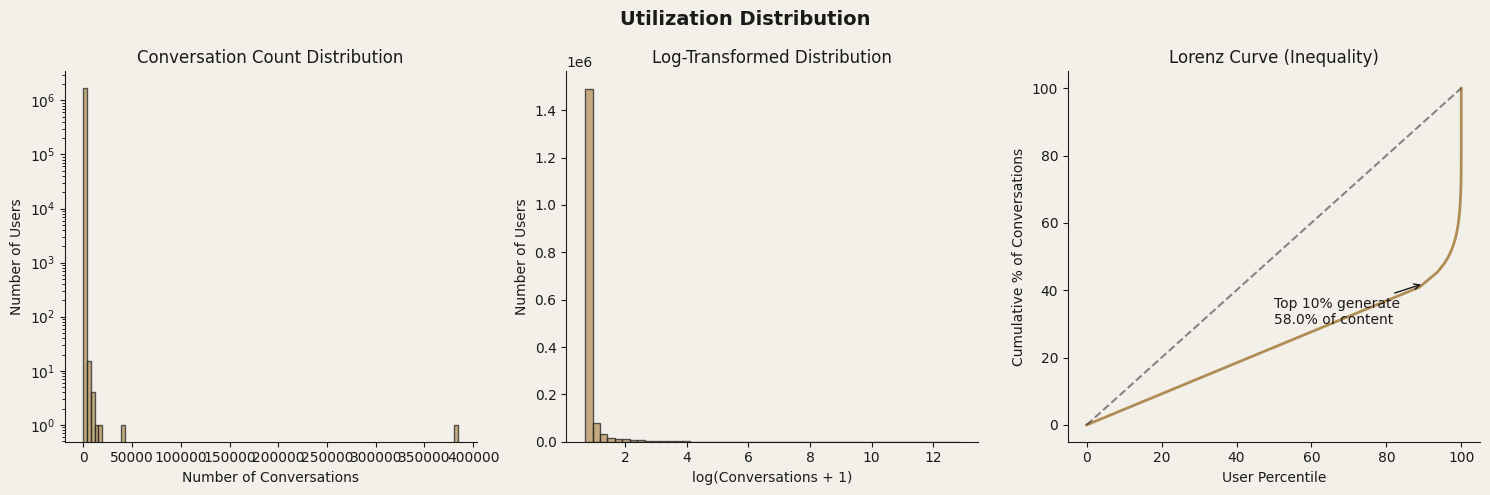


Top 10% of users generate 58.0% of all conversations


In [6]:
# ============================================================
# Data Loading and Utilization Metrics
# ============================================================

print("="*70)
print("DATA LOADING AND UTILIZATION METRICS")
print("="*70)

# Data paths
PROTEST_USERS = '../outputs/data/protest_with_users/*.parquet'
RAW_DATA = '../data/wildchat-raw/data/*.parquet'

# Load preprocessed data
print("Loading data...")
df = pl.scan_parquet(PROTEST_USERS).collect()
print(f"Loaded {len(df):,} conversations")
print(f"Unique users: {df['user_id'].n_unique():,}")

# Compute user-level utilization metrics
print("\nComputing user-level statistics...")
user_stats = df.group_by('user_id').agg([
    pl.len().alias('n_conversations'),
    pl.col('n_turns').sum().alias('total_turns'),
    pl.col('timestamp').min().alias('first_conv_date'),
    pl.col('timestamp').max().alias('last_conv_date'),
])

# Add continuous utilization metrics
user_stats = user_stats.with_columns([
    # Log-transformed counts (handles skew)
    (pl.col('n_conversations') + 1).log().alias('log_conversations'),
    (pl.col('total_turns') + 1).log().alias('log_turns'),
    
    # Active days
    ((pl.col('last_conv_date') - pl.col('first_conv_date')).dt.total_days() + 1)
        .alias('active_days'),
])

# ============================================================
# Filter to Training Data Only (consistent with notebook 07)
# ============================================================
# Use same temporal cutoff as engagement prediction notebook
TRAIN_TEST_CUTOFF = pl.date(2025, 1, 1)

# Filter to training users: first conversation before cutoff
train_user_ids = set(
    user_stats.filter(pl.col('first_conv_date') < TRAIN_TEST_CUTOFF)['user_id'].to_list()
)

print(f"\nFiltering to training data only (first conv < {TRAIN_TEST_CUTOFF})...")
print(f"  All users: {len(user_stats):,}")
print(f"  Training users: {len(train_user_ids):,}")

# Filter user_stats and df to training data only
user_stats = user_stats.filter(pl.col('user_id').is_in(train_user_ids))
df = df.filter(pl.col('user_id').is_in(train_user_ids))

print(f"  Filtered user_stats: {len(user_stats):,} users")
print(f"  Filtered conversations: {len(df):,} conversations")

# Compute percentile ranks (need to do this separately, after filtering)
n_users = len(user_stats)
user_stats = user_stats.sort('n_conversations').with_row_index('rank')
user_stats = user_stats.with_columns([
    ((pl.col('rank') + 1) / n_users * 100).alias('utilization_percentile')
]).drop('rank')

print(f"\nUser-level statistics computed for {len(user_stats):,} training users")
print(f"\nUtilization distribution:")
print(f"  Median conversations: {user_stats['n_conversations'].median():.0f}")
print(f"  Mean conversations: {user_stats['n_conversations'].mean():.1f}")
print(f"  90th percentile: {user_stats['n_conversations'].quantile(0.90):.0f}")
print(f"  99th percentile: {user_stats['n_conversations'].quantile(0.99):.0f}")
print(f"  Max: {user_stats['n_conversations'].max():,}")

# ============================================================
# Visualization: Utilization Distribution
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(BRAND['paper'])
fig.suptitle('Utilization Distribution', fontsize=14, fontweight='bold', color=BRAND['ink'])

# Panel 1: Histogram of conversations (log y-scale)
ax = axes[0]
ax.hist(user_stats['n_conversations'].to_numpy(), bins=100, 
        color=BRAND['gold'], edgecolor=BRAND['ink'], alpha=0.7)
ax.set_xlabel('Number of Conversations')
ax.set_ylabel('Number of Users')
ax.set_yscale('log')
ax.set_title('Conversation Count Distribution')
apply_phronos_style(ax)

# Panel 2: Log-transformed distribution
ax = axes[1]
ax.hist(user_stats['log_conversations'].to_numpy(), bins=50,
        color=BRAND['gold'], edgecolor=BRAND['ink'], alpha=0.7)
ax.set_xlabel('log(Conversations + 1)')
ax.set_ylabel('Number of Users')
ax.set_title('Log-Transformed Distribution')
apply_phronos_style(ax)

# Panel 3: Lorenz curve (inequality)
ax = axes[2]
sorted_convs = np.sort(user_stats['n_conversations'].to_numpy())
cumsum = np.cumsum(sorted_convs) / np.sum(sorted_convs)
ax.plot(np.linspace(0, 100, len(cumsum)), cumsum * 100, 
        color=BRAND['gold'], linewidth=2)
ax.plot([0, 100], [0, 100], color=BRAND['ink'], linestyle='--', alpha=0.5)
ax.set_xlabel('User Percentile')
ax.set_ylabel('Cumulative % of Conversations')
ax.set_title('Lorenz Curve (Inequality)')
apply_phronos_style(ax)

# Annotate inequality metric
top_10_share = 1 - cumsum[int(len(cumsum) * 0.9)]
ax.annotate(f'Top 10% generate\n{top_10_share:.1%} of content', 
            xy=(90, cumsum[int(len(cumsum) * 0.9)] * 100),
            xytext=(50, 30), fontsize=10, color=BRAND['ink'],
            arrowprops=dict(arrowstyle='->', color=BRAND['ink']))

plt.tight_layout()
save_figure(fig, 'utilization_distribution')
plt.show()

print(f"\nTop 10% of users generate {top_10_share:.1%} of all conversations")


In [34]:
# ============================================================
# Stratified Sampling Strategy
# ============================================================
# Strategy: Include ALL high utilizers + stratified sample of others
# This ensures we don't miss any high-utilizer patterns
# 
# NOTE: Analysis limited to TRAINING DATA only (first conv < 2025-01-01)
# This is consistent with notebook 07 (Engagement Prediction)

print("="*70)
print("STRATIFIED SAMPLING STRATEGY (Training Data Only)")
print("="*70)

TOP_PERCENTILE = 90  # Include all users at or above this percentile
OTHER_SAMPLE_SIZE = 100_000  # Random sample from below

# High utilizers: all users at or above 90th percentile
high_util_users = set(
    user_stats.filter(pl.col('utilization_percentile') >= TOP_PERCENTILE)['user_id'].to_list()
)
print(f"High utilizers (>={TOP_PERCENTILE}th percentile): {len(high_util_users):,}")

# Sample from lower utilization users
other_users = user_stats.filter(pl.col('utilization_percentile') < TOP_PERCENTILE)
n_other_sample = min(OTHER_SAMPLE_SIZE, len(other_users))
other_sample_ids = set(
    other_users.sample(n=n_other_sample, seed=RANDOM_STATE)['user_id'].to_list()
)
print(f"Other users sampled: {len(other_sample_ids):,}")

# Combined sample
sample_user_ids = high_util_users | other_sample_ids
print(f"Total sample: {len(sample_user_ids):,}")

# Get first conversation hash for each sampled user
# SAFE PATTERN: sort by timestamp, take first per user
print("\nIdentifying first conversation for each user...")
first_conv_df = df.filter(
    pl.col('user_id').is_in(sample_user_ids)
).sort(['user_id', 'timestamp']).group_by('user_id').first()

first_conv_hashes = set(first_conv_df['conversation_hash'].to_list())
print(f"First conversation hashes identified: {len(first_conv_hashes):,}")

# Create a mapping from user_id to first conv hash for later use
user_to_first_hash = dict(zip(
    first_conv_df['user_id'].to_list(),
    first_conv_df['conversation_hash'].to_list()
))

print("\nSample composition:")
sample_user_stats = user_stats.filter(pl.col('user_id').is_in(sample_user_ids))
print(f"  Users >= 90th percentile: {(sample_user_stats['utilization_percentile'] >= 90).sum():,}")
print(f"  Users >= 99th percentile: {(sample_user_stats['utilization_percentile'] >= 99).sum():,}")


STRATIFIED SAMPLING STRATEGY (Training Data Only)
High utilizers (>=90th percentile): 167,774
Other users sampled: 100,000
Total sample: 267,774

Identifying first conversation for each user...
First conversation hashes identified: 264,569

Sample composition:
  Users >= 90th percentile: 167,774
  Users >= 99th percentile: 16,778


In [39]:
# ============================================================
# First Turn Extraction (File-by-File Processing)
# ============================================================
# CRITICAL: Process raw parquet files one at a time to avoid memory issues
# Use dict to auto-deduplicate by conversation_hash

print("="*70)
print("FIRST TURN EXTRACTION")
print("="*70)

def extract_first_user_turn(conversation):
    """Extract first user message from conversation JSON."""
    if conversation is None:
        return None
    try:
        # Parse if string
        if isinstance(conversation, str):
            conv_list = json.loads(conversation)
        else:
            conv_list = conversation
        
        # Find first user message
        for msg in conv_list:
            if isinstance(msg, dict) and msg.get('role') == 'user':
                content = msg.get('content', '')
                if content:
                    return content[:5000]  # Truncate for embedding efficiency
        return None
    except:
        return None

# Get list of parquet files
parquet_files = sorted(glob.glob(RAW_DATA))
print(f"Raw data files: {len(parquet_files)}")

# File-by-file processing with automatic deduplication via dict
# Dict keys are conversation_hash, so duplicates are automatically handled
first_turns = {}
target_hashes = first_conv_hashes  # From previous cell

print(f"Target conversation hashes: {len(target_hashes):,}")
print("\nExtracting first turns from raw data...")

for file_idx, parquet_file in enumerate(parquet_files):
    # Load only needed columns
    file_data = pl.read_parquet(parquet_file, columns=['conversation_hash', 'conversation'])
    
    # Filter to our target hashes
    file_filtered = file_data.filter(pl.col('conversation_hash').is_in(list(target_hashes)))
    
    if len(file_filtered) == 0:
        del file_data, file_filtered
        gc.collect()
        continue
    
    # Extract first turn for each conversation
    for row in file_filtered.iter_rows(named=True):
        conv_hash = row['conversation_hash']
        if conv_hash not in first_turns:  # Skip if already seen (deduplication)
            first_turn = extract_first_user_turn(row['conversation'])
            if first_turn:
                first_turns[conv_hash] = first_turn
    
    # Progress update
    if (file_idx + 1) % 20 == 0:
        print(f"  Processed {file_idx+1}/{len(parquet_files)} files, found {len(first_turns):,} first turns...")
    
    # Clean up memory
    del file_data, file_filtered
    gc.collect()

print(f"\nExtracted {len(first_turns):,} first turns")
print(f"  Target: {len(target_hashes):,}, Found: {len(first_turns):,}")
if len(first_turns) < len(target_hashes):
    missing = len(target_hashes) - len(first_turns)
    print(f"  Missing: {missing:,} conversations not found in raw data")


FIRST TURN EXTRACTION
Raw data files: 127
Target conversation hashes: 264,569

Extracting first turns from raw data...
  Processed 20/127 files, found 77,927 first turns...
  Processed 40/127 files, found 141,401 first turns...
  Processed 60/127 files, found 192,510 first turns...
  Processed 80/127 files, found 248,118 first turns...
  Processed 100/127 files, found 263,867 first turns...
  Processed 120/127 files, found 263,867 first turns...

Extracted 263,867 first turns
  Target: 264,569, Found: 263,867
  Missing: 702 conversations not found in raw data


In [40]:
# ============================================================
# Build Sample DataFrame
# ============================================================

print("="*70)
print("BUILD SAMPLE DATAFRAME")
print("="*70)

# OPTIMIZED: Use Polars joins instead of slow row-by-row filtering
# Step 1: Create DataFrame from user_to_first_hash mapping
user_hash_df = pl.DataFrame({
    'user_id': list(user_to_first_hash.keys()),
    'conversation_hash': list(user_to_first_hash.values())
})

# Step 2: Filter user_stats to sample users and join with hash mapping
sample_user_stats = user_stats.filter(
    pl.col('user_id').is_in(list(sample_user_ids))
).join(
    user_hash_df,
    on='user_id',
    how='inner'
)

# Step 3: Create DataFrame from first_turns dict
first_turns_df = pl.DataFrame({
    'conversation_hash': list(first_turns.keys()),
    'first_turn': list(first_turns.values())
})

# Step 4: Join with first turns and filter to valid turns
sample_df = sample_user_stats.join(
    first_turns_df,
    on='conversation_hash',
    how='inner'
).filter(
    (pl.col('first_turn').is_not_null()) & 
    (pl.col('first_turn').str.len_chars() > 10)
).select([
    'user_id',
    'conversation_hash',
    'first_turn',
    'n_conversations',
    'log_conversations',
    'utilization_percentile',
    'total_turns',
    'log_turns',
])
print(f"Sample dataframe: {len(sample_df):,} users with valid first turns")

# Verify utilization distribution in sample
print(f"\nSample utilization distribution:")
print(f"  Median percentile: {sample_df['utilization_percentile'].median():.1f}")
print(f"  Mean percentile: {sample_df['utilization_percentile'].mean():.1f}")
print(f"  Users >= 90th percentile: {(sample_df['utilization_percentile'] >= 90).sum():,}")
print(f"  Users >= 99th percentile: {(sample_df['utilization_percentile'] >= 99).sum():,}")

# Clean up intermediate data to free memory
del first_turns
gc.collect()
print("\nMemory cleanup complete.")


BUILD SAMPLE DATAFRAME
Sample dataframe: 251,005 users with valid first turns

Sample utilization distribution:
  Median percentile: 91.8
  Mean percentile: 75.5
  Users >= 90th percentile: 153,020
  Users >= 99th percentile: 15,420

Memory cleanup complete.


In [41]:
# ============================================================
# Generate Semantic Embeddings
# ============================================================

print("="*70)
print("SEMANTIC EMBEDDING GENERATION")
print("="*70)

# Load embedding model
model_name = 'all-MiniLM-L6-v2'  # 384 dimensions, fast, good quality
print(f"Loading embedding model: {model_name}")
embed_model = SentenceTransformer(model_name)

# Get texts for embedding
texts = sample_df['first_turn'].to_list()
print(f"Generating embeddings for {len(texts):,} first turns...")

# Generate embeddings
embeddings = embed_model.encode(
    texts,
    show_progress_bar=True,
    batch_size=256,
    convert_to_numpy=True,
    normalize_embeddings=True  # Cosine similarity = dot product
)

print(f"Embeddings shape: {embeddings.shape}")

# Save embeddings and sample data
import os
output_dir = '../outputs/data'
os.makedirs(output_dir, exist_ok=True)

np.save(f'{output_dir}/first_turn_embeddings.npy', embeddings)
sample_df.write_parquet(f'{output_dir}/embedding_sample.parquet')

print(f"\nSaved:")
print(f"  - {output_dir}/first_turn_embeddings.npy ({embeddings.nbytes / 1024 / 1024:.1f} MB)")
print(f"  - {output_dir}/embedding_sample.parquet")


SEMANTIC EMBEDDING GENERATION
Loading embedding model: all-MiniLM-L6-v2
Generating embeddings for 251,005 first turns...


Batches: 100%|██████████| 981/981 [17:30<00:00,  1.07s/it]  


Embeddings shape: (251005, 384)

Saved:
  - ../outputs/data/first_turn_embeddings.npy (367.7 MB)
  - ../outputs/data/embedding_sample.parquet


In [8]:
# ============================================================
# MULTI-LEVEL EMBEDDING ANALYSIS FOR HIGH UTILIZERS
# ============================================================
# 
# The first-turn embeddings enable PREDICTION (locating new users).
# To CHARACTERIZE high utilizers, we need richer representations:
#
# LEVEL 1: First-turn embeddings (DONE - all sampled users)
#   Purpose: Predict/locate new users
#   Scope: One embedding per user
#
# LEVEL 2: All-turn embeddings (high utilizers only)
#   Purpose: Map full semantic territory of power users
#   Scope: Every first-turn from every conversation
#   Analysis: Topic modeling, density mapping, diversity metrics
#
# LEVEL 3: User-level aggregated embeddings
#   Purpose: Compare users as semantic entities
#   Scope: Centroid + spread of all prompts per user
#   Analysis: User clustering, trajectory analysis
#
# LEVEL 4: Temporal embeddings (early vs late)
#   Purpose: Track semantic drift within users
#   Scope: First N vs last N conversations per power user
#   Analysis: Specialization vs diversification over time
#
# ============================================================

print("="*70)
print("MULTI-LEVEL EMBEDDING ANALYSIS")
print("="*70)
print("\nLevel 1 (first-turn) embeddings already computed.")
print(f"  Shape: {embeddings.shape}")
print(f"  Users: {len(sample_df):,}")


MULTI-LEVEL EMBEDDING ANALYSIS

Level 1 (first-turn) embeddings already computed.


NameError: name 'embeddings' is not defined

In [3]:
# ============================================================
# Define High Utilizer Subset for Deep Analysis
# ============================================================

# Use top 10% of users for detailed analysis
HIGH_UTIL_PERCENTILE = 90

high_util_mask = sample_df['utilization_percentile'] >= HIGH_UTIL_PERCENTILE
high_util_users = sample_df.filter(high_util_mask)
high_util_user_ids = set(high_util_users['user_id'].to_list())

print(f"High utilizers (≥{HIGH_UTIL_PERCENTILE}th percentile): {len(high_util_user_ids):,}")
print(f"  Min conversations: {high_util_users['n_conversations'].min():,}")
print(f"  Median conversations: {high_util_users['n_conversations'].median():,.0f}")
print(f"  Max conversations: {high_util_users['n_conversations'].max():,}")

# Get all conversations from high utilizers
high_util_convs = df.filter(pl.col('user_id').is_in(high_util_user_ids))
print(f"\nTotal conversations from high utilizers: {len(high_util_convs):,}")
print(f"  This is {100 * len(high_util_convs) / len(df):.1f}% of all conversations")


NameError: name 'sample_df' is not defined

In [2]:
# ============================================================
# LEVEL 2: Extract All First-Turns for High Utilizers
# ============================================================

print("="*70)
print("LEVEL 2: ALL-TURN EXTRACTION FOR HIGH UTILIZERS")
print("="*70)

# Get all conversation hashes for high utilizers
high_util_conv_hashes = set(high_util_convs['conversation_hash'].to_list())
print(f"Target conversations: {len(high_util_conv_hashes):,}")

# Recreate first_turns dict from sample_df (since it was deleted in Cell 6)
first_turns = dict(zip(
    sample_df['conversation_hash'].to_list(),
    sample_df['first_turn'].to_list()
))

# Check how many we already have from the first-turn extraction
already_have = sum(1 for h in high_util_conv_hashes if h in first_turns)
need_to_extract = len(high_util_conv_hashes) - already_have
print(f"  Already extracted (first convs): {already_have:,}")
print(f"  Need to extract (subsequent convs): {need_to_extract:,}")

# Extract remaining first-turns
print("\nExtracting additional first turns...")
additional_first_turns = {}
missing_hashes = high_util_conv_hashes - set(first_turns.keys())

for file_idx, parquet_file in enumerate(parquet_files):
    if len(additional_first_turns) >= need_to_extract:
        break
        
    try:
        file_data = pl.read_parquet(parquet_file, columns=['conversation_hash', 'conversation'])
        file_filtered = file_data.filter(pl.col('conversation_hash').is_in(list(missing_hashes)))
        
        for row in file_filtered.iter_rows(named=True):
            conv_hash = row['conversation_hash']
            if conv_hash not in additional_first_turns and conv_hash not in first_turns:
                first_turn = extract_first_user_turn(row['conversation'])
                if first_turn and len(first_turn.strip()) > 10:
                    additional_first_turns[conv_hash] = first_turn
        
        del file_data, file_filtered
        gc.collect()
        
    except Exception as e:
        print(f"  Error processing {parquet_file}: {e}")
        continue
    
    if (file_idx + 1) % 20 == 0:
        print(f"  Processed {file_idx + 1}/{len(parquet_files)} files, "
              f"found {len(additional_first_turns):,} additional turns...")

# Combine with existing first turns
all_high_util_turns = {}
for conv_hash in high_util_conv_hashes:
    if conv_hash in first_turns:
        all_high_util_turns[conv_hash] = first_turns[conv_hash]
    elif conv_hash in additional_first_turns:
        all_high_util_turns[conv_hash] = additional_first_turns[conv_hash]

print(f"\nTotal high utilizer turns extracted: {len(all_high_util_turns):,}")
print(f"  Target: {len(high_util_conv_hashes):,}")
print(f"  Coverage: {100 * len(all_high_util_turns) / len(high_util_conv_hashes):.1f}%")


LEVEL 2: ALL-TURN EXTRACTION FOR HIGH UTILIZERS


NameError: name 'high_util_convs' is not defined

In [13]:
# ============================================================
# Build DataFrame Linking Conversations to Users and Timestamps
# ============================================================

import os

# Check if we can load from saved file (if kernel was restarted)
metadata_file = '../outputs/data/high_util_turn_metadata.parquet'
if os.path.exists(metadata_file):
    print(f"Loading existing high utilizer metadata from {metadata_file}...")
    high_util_turn_df = pl.read_parquet(metadata_file)
    print(f"  Loaded {len(high_util_turn_df):,} conversations")
    print(f"  Users: {high_util_turn_df['user_id'].n_unique():,}")
    print(f"  Conversations per user: {high_util_turn_df.group_by('user_id').len()['len'].mean():.1f} avg")
    print("\n✓ Using saved metadata. You can proceed to Cell 13 (embedding generation).")
else:
    # Need to build from scratch - check for required variables
    try:
        # Check if required variables exist
        if 'high_util_convs' not in globals() or 'all_high_util_turns' not in globals():
            raise NameError("Required variables not found")
        
        print("Building high utilizer conversation dataframe from scratch...")
        
        # Get metadata for each high utilizer conversation
        high_util_conv_metadata = high_util_convs.select([
            'user_id', 'conversation_hash', 'timestamp'
        ]).filter(
            pl.col('conversation_hash').is_in(list(all_high_util_turns.keys()))
        )

        # Add first turn text
        high_util_records = []
        for row in high_util_conv_metadata.iter_rows(named=True):
            text = all_high_util_turns.get(row['conversation_hash'])
            if text:
                high_util_records.append({
                    'user_id': row['user_id'],
                    'conversation_hash': row['conversation_hash'],
                    'timestamp': row['timestamp'],
                    'first_turn': text,
                })

        high_util_turn_df = pl.DataFrame(high_util_records)

        # Add conversation number within each user
        high_util_turn_df = high_util_turn_df.sort(['user_id', 'timestamp']).with_columns([
            pl.col('timestamp').rank('ordinal').over('user_id').alias('conv_number')
        ])

        print(f"High utilizer conversation dataframe: {len(high_util_turn_df):,} conversations")
        print(f"  Users: {high_util_turn_df['user_id'].n_unique():,}")
        print(f"  Conversations per user: {high_util_turn_df.group_by('user_id').len()['len'].mean():.1f} avg")

        # Save metadata for potential resume
        os.makedirs('../outputs/data', exist_ok=True)
        high_util_turn_df.write_parquet(metadata_file)
        print(f"\n✓ Saved metadata to {metadata_file}")
        
    except NameError:
        print("ERROR: Required variables not found!")
        print("\nYou need to run the following cells first:")
        print("  - Cell 9: Define High Utilizer Subset")
        print("  - Cell 10: Extract All First-Turns for High Utilizers")
        print("\nOr if you've run Cell 11 before, the metadata file should exist at:")
        print(f"  {metadata_file}")
        raise


Loading existing high utilizer metadata from ../outputs/data/high_util_turn_metadata.parquet...
  Loaded 1,569,614 conversations
  Users: 152,990
  Conversations per user: 10.3 avg

✓ Using saved metadata. You can proceed to Cell 13 (embedding generation).


In [14]:
# ============================================================
# MINIMAL SETUP FOR RESUMING FROM CELL 13 (Embedding Generation)
# ============================================================
# Run this cell if you restarted the kernel and want to resume from Cell 13
# This restores the minimal dependencies needed

import polars as pl
import numpy as np
import gc
import os
from sentence_transformers import SentenceTransformer

# Load embedding model
print("Loading embedding model...")
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

# Check if high_util_turn_df was saved
metadata_file = '../outputs/data/high_util_turn_metadata.parquet'
if os.path.exists(metadata_file):
    print(f"Loading high utilizer metadata from {metadata_file}...")
    high_util_turn_df = pl.read_parquet(metadata_file)
    print(f"  Loaded {len(high_util_turn_df):,} conversations")
    print(f"  Users: {high_util_turn_df['user_id'].n_unique():,}")
else:
    print(f"ERROR: {metadata_file} not found!")
    print("You need to run Cells 9-12 first to create high_util_turn_df.")
    raise FileNotFoundError(f"Missing {metadata_file}")

# Check checkpoint status
checkpoint_file = '../outputs/data/embedding_checkpoints/high_util_embeddings_checkpoint.npy'
if os.path.exists(checkpoint_file):
    checkpoint_size = len(np.load(checkpoint_file, mmap_mode='r'))
    print(f"\nCheckpoint found: {checkpoint_size:,} embeddings already generated")
    print(f"  Progress: {100 * checkpoint_size / len(high_util_turn_df):.1f}%")
else:
    print("\nNo checkpoint found - will start from beginning")

print("\n✓ Setup complete. You can now run Cell 13 (embedding generation).")


Loading embedding model...
Loading high utilizer metadata from ../outputs/data/high_util_turn_metadata.parquet...
  Loaded 1,569,614 conversations
  Users: 152,990

Checkpoint found: 1,569,614 embeddings already generated
  Progress: 100.0%

✓ Setup complete. You can now run Cell 13 (embedding generation).


In [15]:
# ============================================================
# Build DataFrame Linking Conversations to Users and Timestamps
# ============================================================
# NOTE: This cell is now redundant if Cell 11 already ran and saved the metadata.
# If you see this cell, you can skip it and go directly to Cell 14 (embedding generation).

import os

# Check if we can load from saved file (if kernel was restarted)
metadata_file = '../outputs/data/high_util_turn_metadata.parquet'
if os.path.exists(metadata_file):
    print(f"Loading existing high utilizer metadata from {metadata_file}...")
    high_util_turn_df = pl.read_parquet(metadata_file)
    print(f"  Loaded {len(high_util_turn_df):,} conversations")
    print(f"  Users: {high_util_turn_df['user_id'].n_unique():,}")
    print(f"  Conversations per user: {high_util_turn_df.group_by('user_id').len()['len'].mean():.1f} avg")
    print("\n✓ Using saved metadata. You can proceed to Cell 14 (embedding generation).")
else:
    # Need to build from scratch - check for required variables
    try:
        # Check if required variables exist
        if 'high_util_convs' not in globals() or 'all_high_util_turns' not in globals():
            raise NameError("Required variables not found")
        
        print("Building high utilizer conversation dataframe from scratch...")
        
        # Get metadata for each high utilizer conversation
        high_util_conv_metadata = high_util_convs.select([
            'user_id', 'conversation_hash', 'timestamp'
        ]).filter(
            pl.col('conversation_hash').is_in(list(all_high_util_turns.keys()))
        )

        # Add first turn text
        high_util_records = []
        for row in high_util_conv_metadata.iter_rows(named=True):
            text = all_high_util_turns.get(row['conversation_hash'])
            if text:
                high_util_records.append({
                    'user_id': row['user_id'],
                    'conversation_hash': row['conversation_hash'],
                    'timestamp': row['timestamp'],
                    'first_turn': text,
                })

        high_util_turn_df = pl.DataFrame(high_util_records)

        # Add conversation number within each user
        high_util_turn_df = high_util_turn_df.sort(['user_id', 'timestamp']).with_columns([
            pl.col('timestamp').rank('ordinal').over('user_id').alias('conv_number')
        ])

        print(f"High utilizer conversation dataframe: {len(high_util_turn_df):,} conversations")
        print(f"  Users: {high_util_turn_df['user_id'].n_unique():,}")
        print(f"  Conversations per user: {high_util_turn_df.group_by('user_id').len()['len'].mean():.1f} avg")

        # Save metadata for potential resume
        os.makedirs('../outputs/data', exist_ok=True)
        high_util_turn_df.write_parquet(metadata_file)
        print(f"\n✓ Saved metadata to {metadata_file}")
        
    except NameError:
        print("ERROR: Required variables not found!")
        print("\nYou need to run the following cells first:")
        print("  - Cell 9: Define High Utilizer Subset")
        print("  - Cell 10: Extract All First-Turns for High Utilizers")
        print("\nOr if you've run Cell 11 before, the metadata file should exist at:")
        print(f"  {metadata_file}")
        raise


Loading existing high utilizer metadata from ../outputs/data/high_util_turn_metadata.parquet...
  Loaded 1,569,614 conversations
  Users: 152,990
  Conversations per user: 10.3 avg

✓ Using saved metadata. You can proceed to Cell 14 (embedding generation).


In [16]:
# ============================================================
# LEVEL 2: Generate Embeddings for All High Utilizer Turns
# ============================================================

print("="*70)
print("LEVEL 2: GENERATING ALL-TURN EMBEDDINGS")
print("="*70)

# Extract texts (this creates a copy - will be cleared after processing)
high_util_texts = high_util_turn_df['first_turn'].to_list()
n_texts = len(high_util_texts)
print(f"Texts to embed: {n_texts:,}")

# This is the expensive operation - may take 30-60 min on CPU
# Consider: batch checkpointing, GPU acceleration if available

BATCH_SIZE = 256
CHECKPOINT_EVERY = 50000  # Save progress every N embeddings (reduced for better memory management)

import os
checkpoint_dir = '../outputs/data/embedding_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Check for existing checkpoint
checkpoint_file = f'{checkpoint_dir}/high_util_embeddings_checkpoint.npy'
final_file = '../outputs/data/high_util_all_turn_embeddings.npy'
start_idx = 0

if os.path.exists(checkpoint_file):
    print(f"Found checkpoint at {checkpoint_file}")
    existing_checkpoint = np.load(checkpoint_file, mmap_mode='r')  # Memory-mapped read
    start_idx = len(existing_checkpoint)
    print(f"  Resuming from index {start_idx:,}")
    del existing_checkpoint  # Don't keep in memory
    gc.collect()

# Generate embeddings (with memory-efficient checkpointing)
if start_idx < n_texts:
    remaining_texts = high_util_texts[start_idx:]
    print(f"Generating embeddings for {len(remaining_texts):,} remaining texts...")
    
    # Process in chunks and append to checkpoint file incrementally
    for chunk_start in range(0, len(remaining_texts), CHECKPOINT_EVERY):
        chunk_end = min(chunk_start + CHECKPOINT_EVERY, len(remaining_texts))
        chunk_texts = remaining_texts[chunk_start:chunk_end]
        
        print(f"  Processing chunk {chunk_start + start_idx:,} to {chunk_end + start_idx:,}...")
        chunk_embeddings = embed_model.encode(
            chunk_texts,
            show_progress_bar=False,  # Disable per-chunk progress to reduce output
            batch_size=BATCH_SIZE,
            normalize_embeddings=True
        )
        
        # Append to checkpoint file
        if os.path.exists(checkpoint_file):
            # Load existing checkpoint
            existing = np.load(checkpoint_file)
            # Stack with new chunk
            combined = np.vstack([existing, chunk_embeddings])
            del existing, chunk_embeddings
            gc.collect()
            # Save updated checkpoint
            np.save(checkpoint_file, combined)
            del combined
            gc.collect()
        else:
            # First chunk - create checkpoint
            np.save(checkpoint_file, chunk_embeddings)
            del chunk_embeddings
            gc.collect()
        
        print(f"  ✓ Checkpoint saved: {chunk_end + start_idx:,} / {n_texts:,} embeddings")
    
    # Clear the text list to free memory
    del high_util_texts, remaining_texts
    gc.collect()
    
    # Load final embeddings from checkpoint
    print("Loading final embeddings from checkpoint...")
    high_util_embeddings = np.load(checkpoint_file)
else:
    # All done - load from checkpoint
    print("All embeddings already generated. Loading from checkpoint...")
    high_util_embeddings = np.load(checkpoint_file)
    del high_util_texts  # Free memory
    gc.collect()

print(f"\nAll-turn embeddings shape: {high_util_embeddings.shape}")

# Save final embeddings
print("Saving final embeddings...")
np.save(final_file, high_util_embeddings)
high_util_turn_df.write_parquet('../outputs/data/high_util_turn_metadata.parquet')
print("Saved high utilizer embeddings and metadata.")


LEVEL 2: GENERATING ALL-TURN EMBEDDINGS
Texts to embed: 1,569,614
Found checkpoint at ../outputs/data/embedding_checkpoints/high_util_embeddings_checkpoint.npy
  Resuming from index 1,569,614
All embeddings already generated. Loading from checkpoint...

All-turn embeddings shape: (1569614, 384)
Saving final embeddings...
Saved high utilizer embeddings and metadata.


In [17]:
# ============================================================
# LEVEL 3: USER-LEVEL AGGREGATED EMBEDDINGS
# ============================================================

print("="*70)
print("LEVEL 3: USER-LEVEL AGGREGATED EMBEDDINGS")
print("="*70)

# Recreate high_util_user_ids if needed (for kernel restart recovery)
if 'high_util_user_ids' not in globals():
    print("Recreating high_util_user_ids from high_util_turn_df...")
    high_util_user_ids = set(high_util_turn_df['user_id'].unique().to_list())
    print(f"  Found {len(high_util_user_ids):,} high utilizer users")

# Compute per-user embedding statistics
user_embedding_stats = {}

for user_id in high_util_user_ids:
    user_mask = (high_util_turn_df['user_id'] == user_id).to_numpy()
    user_vecs = high_util_embeddings[user_mask]
    
    if len(user_vecs) < 2:
        continue
    
    # Centroid (mean embedding)
    centroid = user_vecs.mean(axis=0)
    
    # Semantic spread (mean std across dimensions)
    spread = user_vecs.std(axis=0).mean()
    
    # Semantic diameter (max pairwise distance - expensive, sample if needed)
    if len(user_vecs) <= 100:
        from scipy.spatial.distance import pdist
        distances = pdist(user_vecs, metric='cosine')
        diameter = distances.max() if len(distances) > 0 else 0
    else:
        # Sample for large user histories
        sample_idx = np.random.choice(len(user_vecs), size=100, replace=False)
        sample_vecs = user_vecs[sample_idx]
        distances = pdist(sample_vecs, metric='cosine')
        diameter = distances.max() if len(distances) > 0 else 0
    
    user_embedding_stats[user_id] = {
        'centroid': centroid,
        'n_prompts': len(user_vecs),
        'semantic_spread': spread,
        'semantic_diameter': diameter,
    }

print(f"Computed aggregates for {len(user_embedding_stats):,} users")

# Convert to dataframe for analysis
user_agg_records = []
for user_id, stats in user_embedding_stats.items():
    user_agg_records.append({
        'user_id': user_id,
        'n_prompts': stats['n_prompts'],
        'semantic_spread': stats['semantic_spread'],
        'semantic_diameter': stats['semantic_diameter'],
    })

user_agg_df = pl.DataFrame(user_agg_records)

# Join with utilization metrics
user_agg_df = user_agg_df.join(
    user_stats.select(['user_id', 'n_conversations', 'log_conversations', 'utilization_percentile']),
    on='user_id'
)

print(f"\nUser aggregate statistics:")
print(f"  Mean prompts per user: {user_agg_df['n_prompts'].mean():.1f}")
print(f"  Mean semantic spread: {user_agg_df['semantic_spread'].mean():.4f}")
print(f"  Mean semantic diameter: {user_agg_df['semantic_diameter'].mean():.4f}")


LEVEL 3: USER-LEVEL AGGREGATED EMBEDDINGS
Recreating high_util_user_ids from high_util_turn_df...
  Found 152,990 high utilizer users
Computed aggregates for 151,291 users

User aggregate statistics:
  Mean prompts per user: 10.4
  Mean semantic spread: 0.0201
  Mean semantic diameter: 0.5074


SEMANTIC DIVERSITY VS UTILIZATION
Semantic spread vs log(conversations):
  Pearson r = 0.433 (p = 0.0000)

Semantic diameter vs log(conversations):
  Pearson r = 0.384 (p = 0.0000)
Saved: ../outputs/figures/level3_diversity_vs_utilization.png


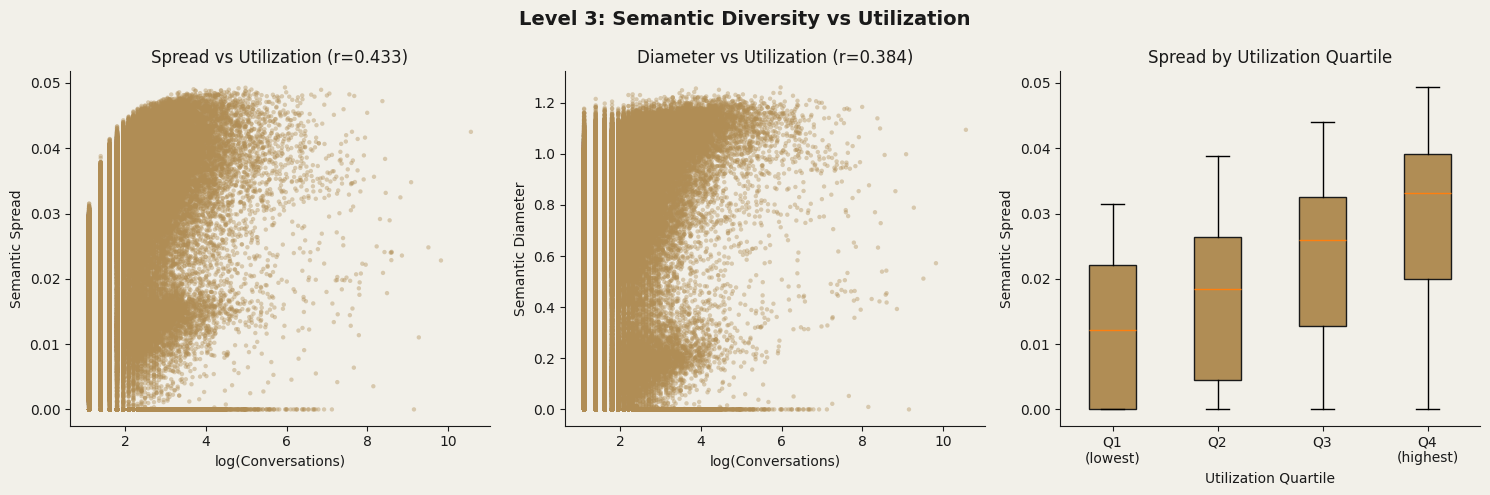

In [18]:
# ============================================================
# Analyze Relationship: Semantic Diversity vs Utilization
# ============================================================

# Check for required variables
if 'user_agg_df' not in globals():
    print("ERROR: user_agg_df not found!")
    print("Please run Cell 15 (Level 3 User Aggregates) first.")
    raise NameError("user_agg_df is not defined - run Cell 15 first")

print("="*70)
print("SEMANTIC DIVERSITY VS UTILIZATION")
print("="*70)

from scipy.stats import pearsonr, spearmanr

# Correlation: spread vs utilization
spread_corr, spread_p = pearsonr(
    user_agg_df['semantic_spread'].to_numpy(),
    user_agg_df['log_conversations'].to_numpy()
)
print(f"Semantic spread vs log(conversations):")
print(f"  Pearson r = {spread_corr:.3f} (p = {spread_p:.4f})")

# Correlation: diameter vs utilization
diam_corr, diam_p = pearsonr(
    user_agg_df['semantic_diameter'].to_numpy(),
    user_agg_df['log_conversations'].to_numpy()
)
print(f"\nSemantic diameter vs log(conversations):")
print(f"  Pearson r = {diam_corr:.3f} (p = {diam_p:.4f})")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(BRAND['paper'])
fig.suptitle('Level 3: Semantic Diversity vs Utilization', fontsize=14, fontweight='bold', color=BRAND['ink'])

# Panel 1: Spread vs utilization
ax = axes[0]
ax.scatter(
    user_agg_df['log_conversations'].to_numpy(),
    user_agg_df['semantic_spread'].to_numpy(),
    c=BRAND['gold'], alpha=0.4, s=10, edgecolors='none'
)
ax.set_xlabel('log(Conversations)')
ax.set_ylabel('Semantic Spread')
ax.set_title(f'Spread vs Utilization (r={spread_corr:.3f})')
apply_phronos_style(ax)

# Panel 2: Diameter vs utilization
ax = axes[1]
ax.scatter(
    user_agg_df['log_conversations'].to_numpy(),
    user_agg_df['semantic_diameter'].to_numpy(),
    c=BRAND['gold'], alpha=0.4, s=10, edgecolors='none'
)
ax.set_xlabel('log(Conversations)')
ax.set_ylabel('Semantic Diameter')
ax.set_title(f'Diameter vs Utilization (r={diam_corr:.3f})')
apply_phronos_style(ax)

# Panel 3: Distribution of spread by utilization quartile
ax = axes[2]
import pandas as pd
quartiles = pd.qcut(user_agg_df['utilization_percentile'].to_numpy(), q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
spread_by_q = [user_agg_df.filter(pl.Series(quartiles == q))['semantic_spread'].to_numpy() 
               for q in ['Q1', 'Q2', 'Q3', 'Q4']]
bp = ax.boxplot(spread_by_q, labels=['Q1\n(lowest)', 'Q2', 'Q3', 'Q4\n(highest)'], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor(BRAND['gold'])
    patch.set_edgecolor(BRAND['ink'])
ax.set_xlabel('Utilization Quartile')
ax.set_ylabel('Semantic Spread')
ax.set_title('Spread by Utilization Quartile')
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'level3_diversity_vs_utilization')
plt.show()


In [19]:
# ============================================================
# LEVEL 4: TEMPORAL EMBEDDINGS (Early vs Late)
# ============================================================

print("="*70)
print("LEVEL 4: TEMPORAL ANALYSIS - SEMANTIC DRIFT")
print("="*70)

N_COMPARE = 10  # Compare first N and last N conversations

temporal_analysis = {}

for user_id in high_util_user_ids:
    user_data = high_util_turn_df.filter(pl.col('user_id') == user_id).sort('conv_number')
    user_mask = (high_util_turn_df['user_id'] == user_id).to_numpy()
    user_vecs = high_util_embeddings[user_mask]
    
    # Need at least 2*N conversations for meaningful comparison
    if len(user_vecs) < 2 * N_COMPARE:
        continue
    
    # Sort vectors by conversation number
    conv_numbers = user_data['conv_number'].to_numpy()
    sort_idx = np.argsort(conv_numbers)
    sorted_vecs = user_vecs[sort_idx]
    
    # Early and late subsets
    early_vecs = sorted_vecs[:N_COMPARE]
    late_vecs = sorted_vecs[-N_COMPARE:]
    
    # Compute centroids
    early_centroid = early_vecs.mean(axis=0)
    late_centroid = late_vecs.mean(axis=0)
    
    # Semantic drift: cosine distance between centroids
    from numpy.linalg import norm
    drift = 1 - np.dot(early_centroid, late_centroid) / (norm(early_centroid) * norm(late_centroid))
    
    # Spread change
    early_spread = early_vecs.std(axis=0).mean()
    late_spread = late_vecs.std(axis=0).mean()
    spread_change = late_spread - early_spread
    
    temporal_analysis[user_id] = {
        'early_centroid': early_centroid,
        'late_centroid': late_centroid,
        'drift': drift,
        'early_spread': early_spread,
        'late_spread': late_spread,
        'spread_change': spread_change,
        'n_conversations': len(user_vecs),
    }

print(f"Temporal analysis computed for {len(temporal_analysis):,} users")
print(f"  (Users with ≥{2*N_COMPARE} conversations)")

# Convert to dataframe (excluding centroid arrays)
temporal_records = []
for uid, stats in temporal_analysis.items():
    temporal_records.append({
        'user_id': uid,
        'drift': stats['drift'],
        'early_spread': stats['early_spread'],
        'late_spread': stats['late_spread'],
        'spread_change': stats['spread_change'],
        'n_conversations': stats['n_conversations'],
    })

temporal_df = pl.DataFrame(temporal_records)

# Summary statistics
print(f"\nSemantic Drift Statistics:")
print(f"  Mean drift: {temporal_df['drift'].mean():.4f}")
print(f"  Median drift: {temporal_df['drift'].median():.4f}")
print(f"  Std drift: {temporal_df['drift'].std():.4f}")

print(f"\nSpread Change (late - early):")
print(f"  Mean: {temporal_df['spread_change'].mean():.4f}")
print(f"  Users who specialized (spread ↓): {(temporal_df['spread_change'] < 0).sum():,} ({100*(temporal_df['spread_change'] < 0).mean():.1f}%)")
print(f"  Users who diversified (spread ↑): {(temporal_df['spread_change'] > 0).sum():,} ({100*(temporal_df['spread_change'] > 0).mean():.1f}%)")


LEVEL 4: TEMPORAL ANALYSIS - SEMANTIC DRIFT
Temporal analysis computed for 10,077 users
  (Users with ≥20 conversations)

Semantic Drift Statistics:
  Mean drift: 0.2979
  Median drift: 0.2524
  Std drift: 0.2456

Spread Change (late - early):
  Mean: -0.0001
  Users who specialized (spread ↓): 4,633 (46.0%)
  Users who diversified (spread ↑): 4,692 (46.6%)


Saved: ../outputs/figures/level4_temporal_analysis.png


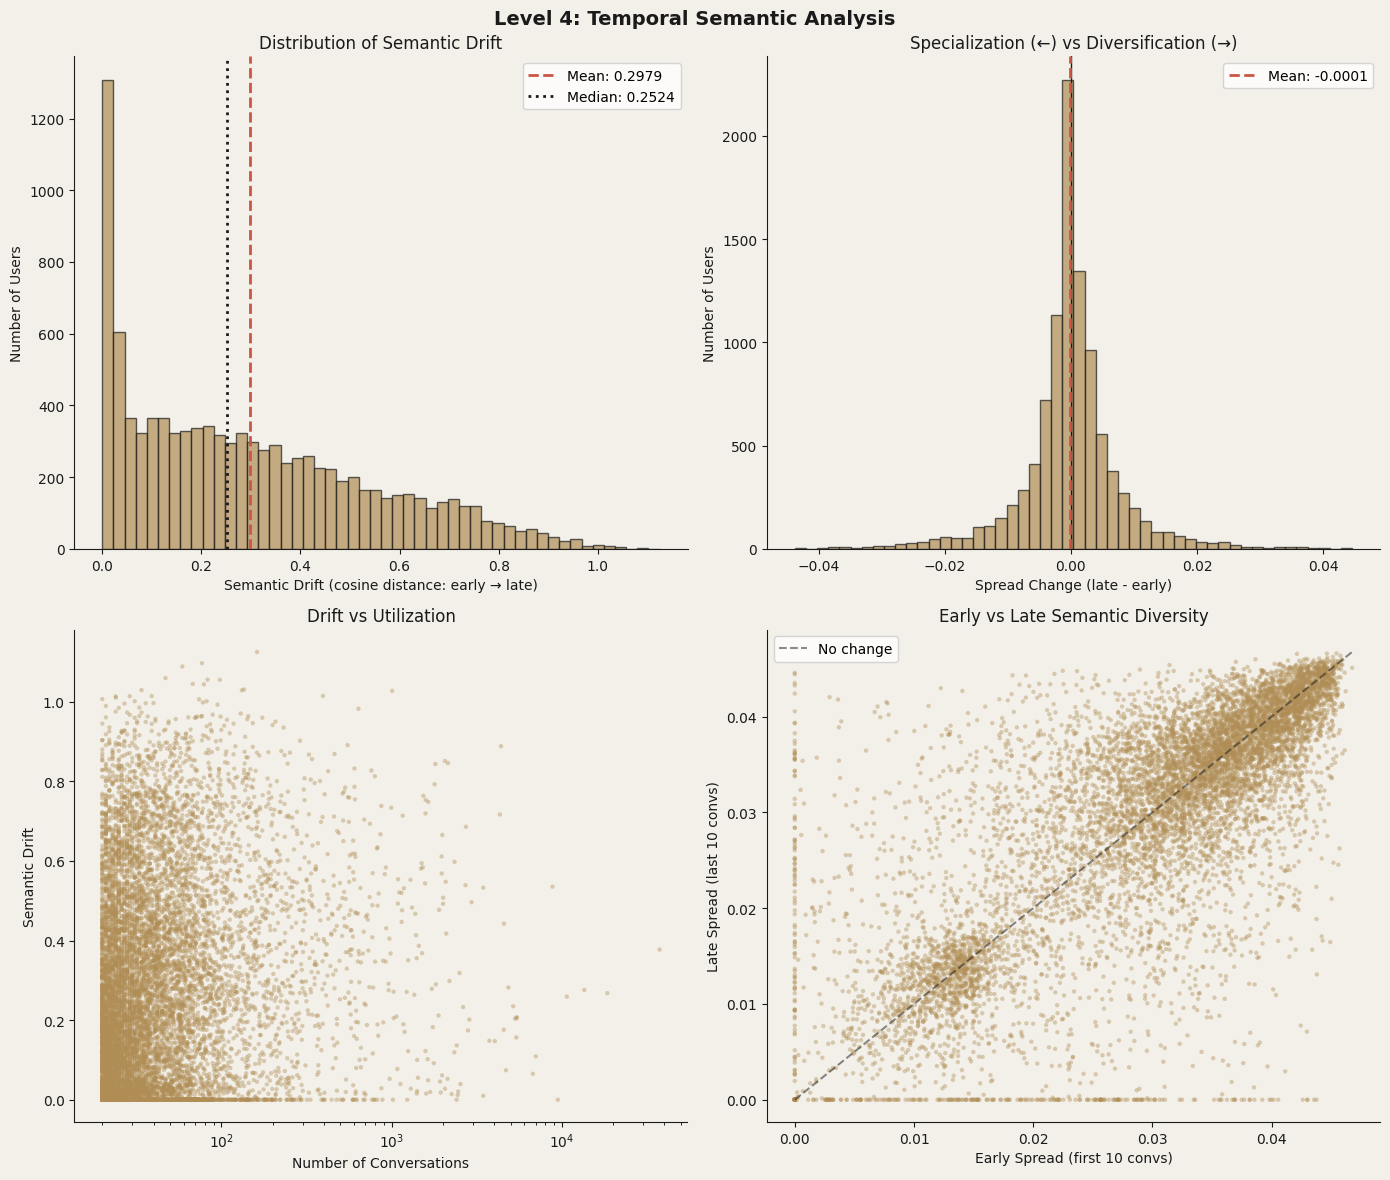

In [20]:
# ============================================================
# Visualize Temporal Patterns
# ============================================================

# Check for required variables
if 'temporal_df' not in globals():
    print("ERROR: temporal_df not found!")
    print("Please run Cell 17 (Level 4 Temporal Analysis) first.")
    raise NameError("temporal_df is not defined - run Cell 17 first")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.patch.set_facecolor(BRAND['paper'])
fig.suptitle('Level 4: Temporal Semantic Analysis', fontsize=14, fontweight='bold', color=BRAND['ink'])

# Panel 1: Distribution of semantic drift
ax = axes[0, 0]
ax.hist(temporal_df['drift'].to_numpy(), bins=50, color=BRAND['gold'], edgecolor=BRAND['ink'], alpha=0.7)
ax.axvline(x=temporal_df['drift'].mean(), color=BRAND['alert'], linestyle='--', linewidth=2,
           label=f"Mean: {temporal_df['drift'].mean():.4f}")
ax.axvline(x=temporal_df['drift'].median(), color=BRAND['ink'], linestyle=':', linewidth=2,
           label=f"Median: {temporal_df['drift'].median():.4f}")
ax.set_xlabel('Semantic Drift (cosine distance: early → late)')
ax.set_ylabel('Number of Users')
ax.set_title('Distribution of Semantic Drift')
ax.legend()
apply_phronos_style(ax)

# Panel 2: Distribution of spread change
ax = axes[0, 1]
ax.hist(temporal_df['spread_change'].to_numpy(), bins=50, color=BRAND['gold'], edgecolor=BRAND['ink'], alpha=0.7)
ax.axvline(x=0, color=BRAND['ink'], linestyle='-', linewidth=1)
ax.axvline(x=temporal_df['spread_change'].mean(), color=BRAND['alert'], linestyle='--', linewidth=2,
           label=f"Mean: {temporal_df['spread_change'].mean():.4f}")
ax.set_xlabel('Spread Change (late - early)')
ax.set_ylabel('Number of Users')
ax.set_title('Specialization (←) vs Diversification (→)')
ax.legend()
apply_phronos_style(ax)

# Panel 3: Drift vs utilization
ax = axes[1, 0]
ax.scatter(
    temporal_df['n_conversations'].to_numpy(),
    temporal_df['drift'].to_numpy(),
    c=BRAND['gold'], alpha=0.4, s=10, edgecolors='none'
)
ax.set_xlabel('Number of Conversations')
ax.set_ylabel('Semantic Drift')
ax.set_xscale('log')
ax.set_title('Drift vs Utilization')
apply_phronos_style(ax)

# Panel 4: Early spread vs late spread
ax = axes[1, 1]
max_spread = max(temporal_df['early_spread'].max(), temporal_df['late_spread'].max())
ax.scatter(
    temporal_df['early_spread'].to_numpy(),
    temporal_df['late_spread'].to_numpy(),
    c=BRAND['gold'], alpha=0.4, s=10, edgecolors='none'
)
ax.plot([0, max_spread], [0, max_spread], color=BRAND['ink'], linestyle='--', alpha=0.5, label='No change')
ax.set_xlabel('Early Spread (first 10 convs)')
ax.set_ylabel('Late Spread (last 10 convs)')
ax.set_title('Early vs Late Semantic Diversity')
ax.legend()
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'level4_temporal_analysis')
plt.show()


In [21]:
# ============================================================
# TOPIC MODELING ON ALL HIGH UTILIZER TURNS
# ============================================================

print("="*70)
print("TOPIC MODELING: FULL HIGH UTILIZER CORPUS")
print("="*70)

# Recreate high_util_texts if needed (for kernel restart recovery)
if 'high_util_texts' not in globals():
    print("Recreating high_util_texts from high_util_turn_df...")
    high_util_texts = high_util_turn_df['first_turn'].to_list()
    print(f"  {len(high_util_texts):,} texts loaded")

# Fit BERTopic on all high utilizer turns
# This gives a richer picture than first-turn-only topics

# OPTIMIZATION: Sample data for UMAP (1.5M points takes hours on CPU)
# Fit UMAP on 200k sample (~20-30 min), then transform all points
SAMPLE_SIZE_FOR_UMAP = 200000
n_total = len(high_util_embeddings)

if n_total > SAMPLE_SIZE_FOR_UMAP:
    print(f"Sampling {SAMPLE_SIZE_FOR_UMAP:,} from {n_total:,} for UMAP fitting...")
    np.random.seed(RANDOM_STATE)
    sample_indices = np.random.choice(n_total, size=SAMPLE_SIZE_FOR_UMAP, replace=False)
    high_util_embeddings_sample = high_util_embeddings[sample_indices]
else:
    sample_indices = None
    high_util_embeddings_sample = high_util_embeddings

print("\nFitting UMAP (should take ~20-30 min with sampling)...")
high_util_reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=RANDOM_STATE,
    low_memory=True,
    verbose=True
)
high_util_embedding_2d_sample = high_util_reducer.fit_transform(high_util_embeddings_sample)

# Transform all embeddings using the fitted reducer
if sample_indices is not None:
    print(f"\nTransforming all {n_total:,} embeddings...")
    BATCH_SIZE_UMAP = 50000
    high_util_embedding_2d_list = []
    for i in range(0, n_total, BATCH_SIZE_UMAP):
        batch = high_util_embeddings[i:i+BATCH_SIZE_UMAP]
        batch_2d = high_util_reducer.transform(batch)
        high_util_embedding_2d_list.append(batch_2d)
        print(f"  {min(i+BATCH_SIZE_UMAP, n_total):,} / {n_total:,}")
    high_util_embedding_2d = np.vstack(high_util_embedding_2d_list)
    del high_util_embedding_2d_list; gc.collect()
else:
    high_util_embedding_2d = high_util_embedding_2d_sample

# BERTopic with PRE-COMPUTED embeddings
# Create a dummy UMAP class that just returns the pre-computed 2D embeddings
# This avoids BERTopic re-running UMAP (which takes hours on 1.5M points)

print("\nSetting up BERTopic with pre-computed UMAP embeddings...")

class PrecomputedUMAP:
    """Dummy UMAP model that returns pre-computed embeddings."""
    def __init__(self, precomputed_embeddings):
        self.embedding_ = precomputed_embeddings
        self.precomputed_embeddings = precomputed_embeddings
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        # For transform, we just return the pre-computed embeddings
        # This assumes X has the same length as precomputed_embeddings
        return self.precomputed_embeddings
    
    def fit_transform(self, X, y=None):
        self.fit(X, y)
        return self.precomputed_embeddings

# Create dummy UMAP with our pre-computed 2D embeddings
dummy_umap = PrecomputedUMAP(high_util_embedding_2d)
print(f"  Pre-computed UMAP embeddings shape: {high_util_embedding_2d.shape}")

high_util_vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=20,  # Higher threshold for larger corpus
    max_df=0.5
)

# Use HDBSCAN with settings appropriate for large dataset
from hdbscan import HDBSCAN
hdbscan_model = HDBSCAN(
    min_cluster_size=500,  # Larger clusters for 1.5M points
    min_samples=50,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

high_util_topic_model = BERTopic(
    embedding_model=embed_model,
    umap_model=dummy_umap,  # Use pre-computed embeddings
    hdbscan_model=hdbscan_model,
    vectorizer_model=high_util_vectorizer,
    nr_topics='auto',
    top_n_words=10,
    verbose=True
)

print("Fitting BERTopic (should take ~10-20 min with pre-computed UMAP)...")
high_util_topics, high_util_probs = high_util_topic_model.fit_transform(
    high_util_texts, 
    high_util_embeddings
)

n_high_util_topics = len(set(high_util_topics)) - 1  # -1 for outlier topic
print(f"\nTopics discovered in high utilizer corpus: {n_high_util_topics}")

# Add topics to turn dataframe
high_util_turn_df = high_util_turn_df.with_columns([
    pl.Series('topic', high_util_topics)
])


TOPIC MODELING: FULL HIGH UTILIZER CORPUS
Recreating high_util_texts from high_util_turn_df...
  1,569,614 texts loaded
Sampling 200,000 from 1,569,614 for UMAP fitting...

Fitting UMAP (should take ~20-30 min with sampling)...
UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Fri Jan  2 22:30:31 2026 Construct fuzzy simplicial set
Fri Jan  2 22:30:31 2026 Finding Nearest Neighbors
Fri Jan  2 22:30:31 2026 Building RP forest with 27 trees
Fri Jan  2 22:30:45 2026 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	 3  /  18
	 4  /  18
	 5  /  18
	Stopping threshold met -- exiting after 5 iterations
Fri Jan  2 22:31:28 2026 Finished Nearest Neighbor Search
Fri Jan  2 22:31:30 2026 Construct embedding


Epochs completed:   0%|            1/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  11%| █          22/200 [00:09]

	completed  20  /  200 epochs


...

Epochs completed: 100%| ██████████ 30/30 [00:00]

	completed  21  /  30 epochs
	completed  24  /  30 epochs
	completed  27  /  30 epochs
  1,569,614 / 1,569,614



Setting up BERTopic with pre-computed UMAP embeddings...
  Pre-computed UMAP embeddings shape: (1569614, 2)
Fitting BERTopic (should take ~10-20 min with pre-computed UMAP)...


2026-01-03 00:03:07,032 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-03 00:03:07,033 - BERTopic - Dimensionality - Completed ✓
2026-01-03 00:03:07,038 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-03 00:32:11,795 - BERTopic - Cluster - Completed ✓
2026-01-03 00:32:11,796 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-01-03 01:33:49,207 - BERTopic - Representation - Completed ✓
2026-01-03 01:33:49,415 - BERTopic - Topic reduction - Reducing number of topics
2026-01-03 01:33:49,802 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-03 02:10:07,153 - BERTopic - Representation - Completed ✓
2026-01-03 02:10:07,337 - BERTopic - Topic reduction - Reduced number of topics from 469 to 258



Topics discovered in high utilizer corpus: 257


TOPIC COMPARISON: FIRST-TURN VS ALL-TURN
First-turn topics not available (skipping comparison).
  To enable: run the original topic modeling cells on sample_df first.

All-turn topic distribution (high utilizers):
  Topic 0: 103,063 (ar, detailed description, prompts, imagine prompt, ar 16)
  Topic 1: 89,087 (напиши, как, что, тему, ли)
  Topic 2: 75,529 (franchise, novel, manga, anime, steven)
  Topic 3: 58,847 (que, el, para, se, los)
  Topic 4: 50,423 (что, не, это, но, она)
  Topic 5: 38,180 (financial, bank, customer, cameron, payment)
  Topic 6: 37,502 (translation, chinese, checkout, install, ubuntu)
  Topic 7: 35,480 (không, và, câu, có, hỏi)
  Topic 8: 28,605 (et, les, une, est, pour)
Saved: ../outputs/figures/high_util_topic_landscape.png


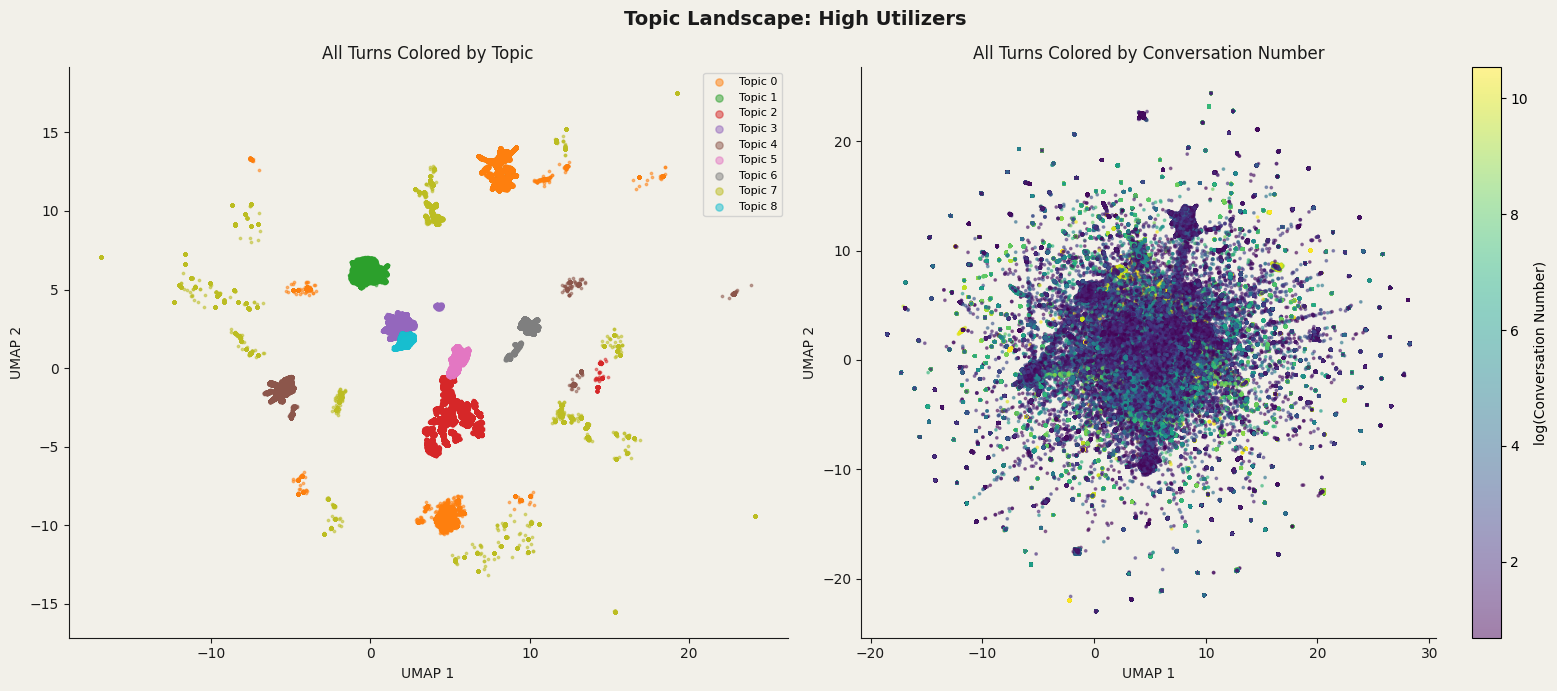

In [24]:
# ============================================================
# Compare Topics: First-Turn vs All-Turn
# ============================================================

print("="*70)
print("TOPIC COMPARISON: FIRST-TURN VS ALL-TURN")
print("="*70)

import pandas as pd

# First-turn topics (from original sample analysis - skip if not available)
if 'topics' in globals() and 'topic_model' in globals() and 'sample_df' in globals():
    first_turn_high_util_mask = sample_df['user_id'].is_in(high_util_user_ids)
    first_turn_topics_high_util = np.array(topics)[first_turn_high_util_mask.to_numpy()]

    print("First-turn topic distribution (high utilizers):")
    first_turn_topic_counts = pd.Series(first_turn_topics_high_util).value_counts().head(10)
    for topic_id, count in first_turn_topic_counts.items():
        if topic_id >= 0:
            topic_words = topic_model.get_topic(topic_id)
            if topic_words:
                words = ', '.join([w[0] for w in topic_words[:5]])
                print(f"  Topic {topic_id}: {count:,} ({words})")
else:
    print("First-turn topics not available (skipping comparison).")
    print("  To enable: run the original topic modeling cells on sample_df first.")

print("\nAll-turn topic distribution (high utilizers):")
all_turn_topic_counts = pd.Series(high_util_topics).value_counts().head(10)
for topic_id, count in all_turn_topic_counts.items():
    if topic_id >= 0:
        topic_words = high_util_topic_model.get_topic(topic_id)
        if topic_words:
            words = ', '.join([w[0] for w in topic_words[:5]])
            print(f"  Topic {topic_id}: {count:,} ({words})")

# Visualization: Topic landscape for high utilizers
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BRAND['paper'])
fig.suptitle('Topic Landscape: High Utilizers', fontsize=14, fontweight='bold', color=BRAND['ink'])

# Panel 1: UMAP colored by topic
ax = axes[0]
# Color by top 10 topics
top_topics = all_turn_topic_counts.head(10).index.tolist()
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for i, topic_id in enumerate(top_topics):
    if topic_id < 0:
        continue
    mask = np.array(high_util_topics) == topic_id
    ax.scatter(
        high_util_embedding_2d[mask, 0],
        high_util_embedding_2d[mask, 1],
        c=[colors[i]], s=3, alpha=0.5,
        label=f"Topic {topic_id}"
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('All Turns Colored by Topic')
ax.legend(markerscale=3, fontsize=8, facecolor=BRAND['paper'])
apply_phronos_style(ax)

# Panel 2: UMAP colored by conversation number (temporal)
ax = axes[1]
conv_numbers = high_util_turn_df['conv_number'].to_numpy()
scatter = ax.scatter(
    high_util_embedding_2d[:, 0],
    high_util_embedding_2d[:, 1],
    c=np.log1p(conv_numbers),
    cmap='viridis', s=3, alpha=0.5
)
plt.colorbar(scatter, ax=ax, label='log(Conversation Number)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('All Turns Colored by Conversation Number')
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'high_util_topic_landscape')
plt.show()


In [25]:
# ============================================================
# User-Level Topic Diversity Analysis
# ============================================================

print("="*70)
print("USER-LEVEL TOPIC DIVERSITY")
print("="*70)

from collections import Counter
import math

def compute_topic_entropy(topics):
    """Compute Shannon entropy of topic distribution."""
    counts = Counter(topics)
    total = sum(counts.values())
    if total <= 1:
        return 0.0
    probs = [c / total for c in counts.values()]
    return -sum(p * math.log2(p) for p in probs if p > 0)

# Compute topic entropy per user
user_topic_entropy = {}
for user_id in high_util_user_ids:
    user_topics = high_util_turn_df.filter(pl.col('user_id') == user_id)['topic'].to_list()
    if len(user_topics) >= 5:  # Need enough data for meaningful entropy
        user_topic_entropy[user_id] = {
            'topic_entropy': compute_topic_entropy(user_topics),
            'n_unique_topics': len(set(user_topics)),
            'n_conversations': len(user_topics),
            'dominant_topic': Counter(user_topics).most_common(1)[0][0],
            'dominant_topic_pct': Counter(user_topics).most_common(1)[0][1] / len(user_topics),
        }

# Convert to dataframe
topic_entropy_df = pl.DataFrame([{'user_id': uid, **stats} for uid, stats in user_topic_entropy.items()])
topic_entropy_df = topic_entropy_df.join(
    user_stats.select(['user_id', 'log_conversations', 'utilization_percentile']),
    on='user_id'
)

print(f"Topic diversity computed for {len(topic_entropy_df):,} users")
print(f"\nTopic Entropy Statistics:")
print(f"  Mean: {topic_entropy_df['topic_entropy'].mean():.3f}")
print(f"  Median: {topic_entropy_df['topic_entropy'].median():.3f}")
print(f"  Range: [{topic_entropy_df['topic_entropy'].min():.3f}, {topic_entropy_df['topic_entropy'].max():.3f}]")

print(f"\nDominant Topic Concentration:")
print(f"  Mean % in dominant topic: {100 * topic_entropy_df['dominant_topic_pct'].mean():.1f}%")
print(f"  Users with >50% in one topic: {(topic_entropy_df['dominant_topic_pct'] > 0.5).sum():,} "
      f"({100 * (topic_entropy_df['dominant_topic_pct'] > 0.5).mean():.1f}%)")

# Correlation with utilization
entropy_corr, entropy_p = pearsonr(
    topic_entropy_df['topic_entropy'].to_numpy(),
    topic_entropy_df['log_conversations'].to_numpy()
)
print(f"\nTopic entropy vs log(conversations): r = {entropy_corr:.3f} (p = {entropy_p:.4f})")


USER-LEVEL TOPIC DIVERSITY
Topic diversity computed for 52,293 users

Topic Entropy Statistics:
  Mean: 0.953
  Median: 0.959
  Range: [-0.000, 4.094]

Dominant Topic Concentration:
  Mean % in dominant topic: 71.6%
  Users with >50% in one topic: 40,924 (78.3%)

Topic entropy vs log(conversations): r = 0.250 (p = 0.0000)


In [ ]:
# ============================================================
# UPDATED OUTPUT SUMMARY
# ============================================================

print("="*70)
print("MULTI-LEVEL ANALYSIS COMPLETE")
print("="*70)

# Build summary with available data (handles partial runs / kernel restarts)
ml_outputs = {}

# Level 1
if 'embeddings' in globals():
    ml_outputs['Level 1 (First-turn)'] = {
        'Embeddings': f'{embeddings.shape[0]:,} users × {embeddings.shape[1]} dims',
        'Purpose': 'Prediction/location of new users',
    }
else:
    ml_outputs['Level 1 (First-turn)'] = {'Status': '(not run)', 'Purpose': 'Prediction/location of new users'}

# Level 2
if 'high_util_embeddings' in globals():
    level2 = {
        'Embeddings': f'{high_util_embeddings.shape[0]:,} turns × {high_util_embeddings.shape[1]} dims',
        'Purpose': 'Full semantic territory of power users',
    }
    if 'n_high_util_topics' in globals():
        level2['Topics discovered'] = n_high_util_topics
    ml_outputs['Level 2 (All-turn)'] = level2
else:
    ml_outputs['Level 2 (All-turn)'] = {'Status': '(not run)', 'Purpose': 'Full semantic territory of power users'}

# Level 3
if 'user_embedding_stats' in globals() and 'spread_corr' in globals():
    ml_outputs['Level 3 (User aggregates)'] = {
        'Users': f'{len(user_embedding_stats):,}',
        'Spread-utilization correlation': f'r = {spread_corr:.3f}',
        'Purpose': 'Compare users as semantic entities',
    }
else:
    ml_outputs['Level 3 (User aggregates)'] = {'Status': '(not run)', 'Purpose': 'Compare users as semantic entities'}

# Level 4
if 'temporal_analysis' in globals() and 'temporal_df' in globals():
    ml_outputs['Level 4 (Temporal)'] = {
        'Users analyzed': f'{len(temporal_analysis):,}',
        'Mean semantic drift': f'{temporal_df["drift"].mean():.4f}',
        'Specializers vs diversifiers': f'{(temporal_df["spread_change"] < 0).sum()} vs {(temporal_df["spread_change"] > 0).sum()}',
        'Purpose': 'Track semantic evolution within users',
    }
else:
    ml_outputs['Level 4 (Temporal)'] = {'Status': '(not run)', 'Purpose': 'Track semantic evolution within users'}

for level, level_info in ml_outputs.items():
    print(f"\n{level}:")
    for key, value in level_info.items():
        print(f"  {key}: {value}")

print("\n" + "="*70)
print("Data files saved:")
print("  - high_util_all_turn_embeddings.npy")
print("  - high_util_turn_metadata.parquet")
print("  - Checkpoint files in embedding_checkpoints/")
print("\nFigures saved:")
print("  - level3_diversity_vs_utilization.png")
print("  - level4_temporal_analysis.png")
print("  - high_util_topic_landscape.png")


MULTI-LEVEL ANALYSIS COMPLETE

Level 1 (First-turn):
  Status: (not run)
  Purpose: Prediction/location of new users

Level 2 (All-turn):
  Embeddings: 1,569,614 turns × 384 dims
  Purpose: Full semantic territory of power users
  Topics discovered: 257

Level 3 (User aggregates):
  Users: 151,291
  Spread-utilization correlation: r = 0.433
  Purpose: Compare users as semantic entities

Level 4 (Temporal):
  Users analyzed: 10,077
  Mean semantic drift: 0.2979
  Specializers vs diversifiers: 4633 vs 4692
  Purpose: Track semantic evolution within users

Data files saved:
  - high_util_all_turn_embeddings.npy
  - high_util_turn_metadata.parquet
  - Checkpoint files in embedding_checkpoints/

Figures saved:
  - level3_diversity_vs_utilization.png
  - level4_temporal_analysis.png
  - high_util_topic_landscape.png


UMAP DIMENSIONALITY REDUCTION (First-Turn Sample)
Fitting UMAP (this may take a few minutes)...
UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Sat Jan  3 09:09:39 2026 Construct fuzzy simplicial set
Sat Jan  3 09:09:39 2026 Finding Nearest Neighbors
Sat Jan  3 09:09:39 2026 Building RP forest with 30 trees
Sat Jan  3 09:09:49 2026 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	 3  /  18
	 4  /  18
	 5  /  18
	Stopping threshold met -- exiting after 5 iterations
Sat Jan  3 09:10:26 2026 Finished Nearest Neighbor Search
Sat Jan  3 09:10:27 2026 Construct embedding


Epochs completed:   1%|            2/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  10%| █          21/200 [17:11]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  90%| █████████  181/200 [37:21]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [37:37]


Sat Jan  3 10:19:44 2026 Finished embedding
UMAP embedding shape: (251005, 2)
Saved: ../outputs/figures/umap_utilization_overview.png


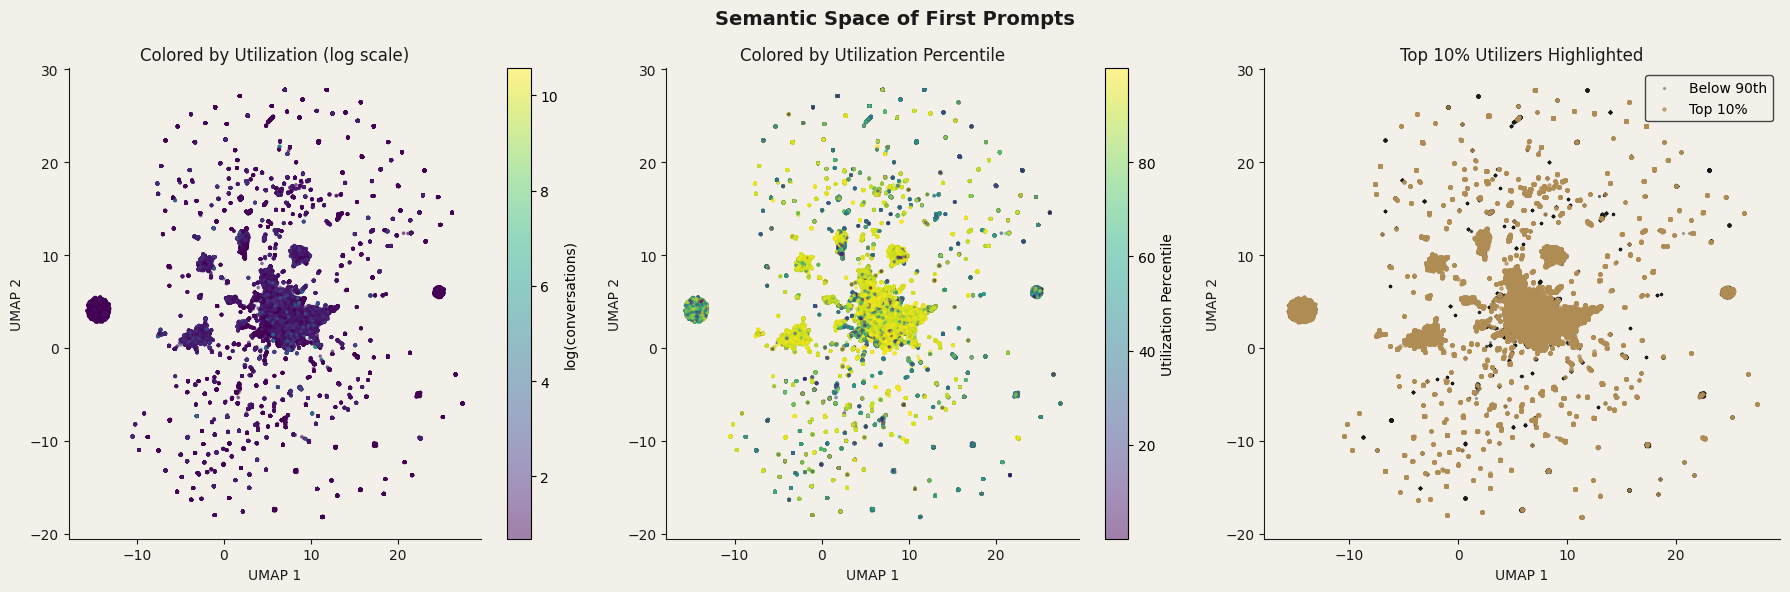

In [42]:
# ============================================================
# UMAP Dimensionality Reduction (First-Turn Sample)
# ============================================================

print("="*70)
print("UMAP DIMENSIONALITY REDUCTION (First-Turn Sample)")
print("="*70)

# Check if embeddings are available
if 'embeddings' not in globals():
    # Try to load from saved file (Cell 7 saves to first_turn_embeddings.npy)
    emb_path = '../outputs/data/first_turn_embeddings.npy'
    if os.path.exists(emb_path):
        print(f"Loading embeddings from {emb_path}...")
        embeddings = np.load(emb_path)
        print(f"Loaded embeddings: {embeddings.shape}")
    else:
        raise NameError(
            "embeddings not defined. Run Cell 7 (Generate Semantic Embeddings) first, "
            "or ensure first_turn_embeddings.npy exists."
        )

# Also need sample_df for adding UMAP coordinates
if 'sample_df' not in globals():
    sample_path = '../outputs/data/embedding_sample.parquet'
    if os.path.exists(sample_path):
        print(f"Loading sample_df from {sample_path}...")
        sample_df = pl.read_parquet(sample_path)
        print(f"Loaded sample_df: {sample_df.shape}")
    else:
        raise NameError(
            "sample_df not defined. Run cells 3-6 first, "
            "or ensure embedding_sample.parquet exists."
        )

# Validate embeddings match sample_df
if embeddings.shape[0] != len(sample_df):
    print(f"⚠️ Shape mismatch: embeddings={embeddings.shape[0]:,}, sample_df={len(sample_df):,}")
    print("Truncating sample_df to match embeddings (assuming embeddings are from first N rows)...")
    sample_df = sample_df.head(embeddings.shape[0])
    print(f"Truncated sample_df to {len(sample_df):,} rows")

# Fit UMAP
print("Fitting UMAP (this may take a few minutes)...")
reducer = umap.UMAP(
    n_neighbors=30,      # Balance local/global structure
    min_dist=0.1,        # Allow tight clusters
    n_components=2,      # For visualization
    metric='cosine',     # Match embedding normalization
    random_state=RANDOM_STATE,
    verbose=True
)

embedding_2d = reducer.fit_transform(embeddings)
print(f"UMAP embedding shape: {embedding_2d.shape}")

# Add to sample dataframe
sample_df = sample_df.with_columns([
    pl.Series('umap_x', embedding_2d[:, 0]),
    pl.Series('umap_y', embedding_2d[:, 1]),
])

# ============================================================
# Visualization: UMAP colored by utilization
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BRAND['paper'])
fig.suptitle('Semantic Space of First Prompts', fontsize=14, fontweight='bold', color=BRAND['ink'])

# Panel 1: Colored by log(conversations)
ax = axes[0]
scatter = ax.scatter(
    embedding_2d[:, 0], embedding_2d[:, 1],
    c=sample_df['log_conversations'].to_numpy(),
    cmap='viridis', alpha=0.5, s=3, rasterized=True
)
plt.colorbar(scatter, ax=ax, label='log(conversations)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Colored by Utilization (log scale)')
apply_phronos_style(ax)

# Panel 2: Colored by utilization percentile
ax = axes[1]
scatter = ax.scatter(
    embedding_2d[:, 0], embedding_2d[:, 1],
    c=sample_df['utilization_percentile'].to_numpy(),
    cmap='viridis', alpha=0.5, s=3, rasterized=True
)
plt.colorbar(scatter, ax=ax, label='Utilization Percentile')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Colored by Utilization Percentile')
apply_phronos_style(ax)

# Panel 3: Binary high/low utilization
ax = axes[2]
is_high = (sample_df['utilization_percentile'] >= 90).to_numpy()

# Plot low utilizers first (in background)
ax.scatter(
    embedding_2d[~is_high, 0], embedding_2d[~is_high, 1],
    c=BRAND['ink'], alpha=0.3, s=2, label='Below 90th', rasterized=True
)
# Plot high utilizers on top
ax.scatter(
    embedding_2d[is_high, 0], embedding_2d[is_high, 1],
    c=BRAND['gold'], alpha=0.7, s=5, label='Top 10%', rasterized=True
)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Top 10% Utilizers Highlighted')
ax.legend(facecolor=BRAND['paper'], edgecolor=BRAND['ink'])
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'umap_utilization_overview')
plt.show()


DENSITY ANALYSIS: HIGH VS LOW UTILIZER REGIONS
Saved: ../outputs/figures/density_by_utilization_band.png


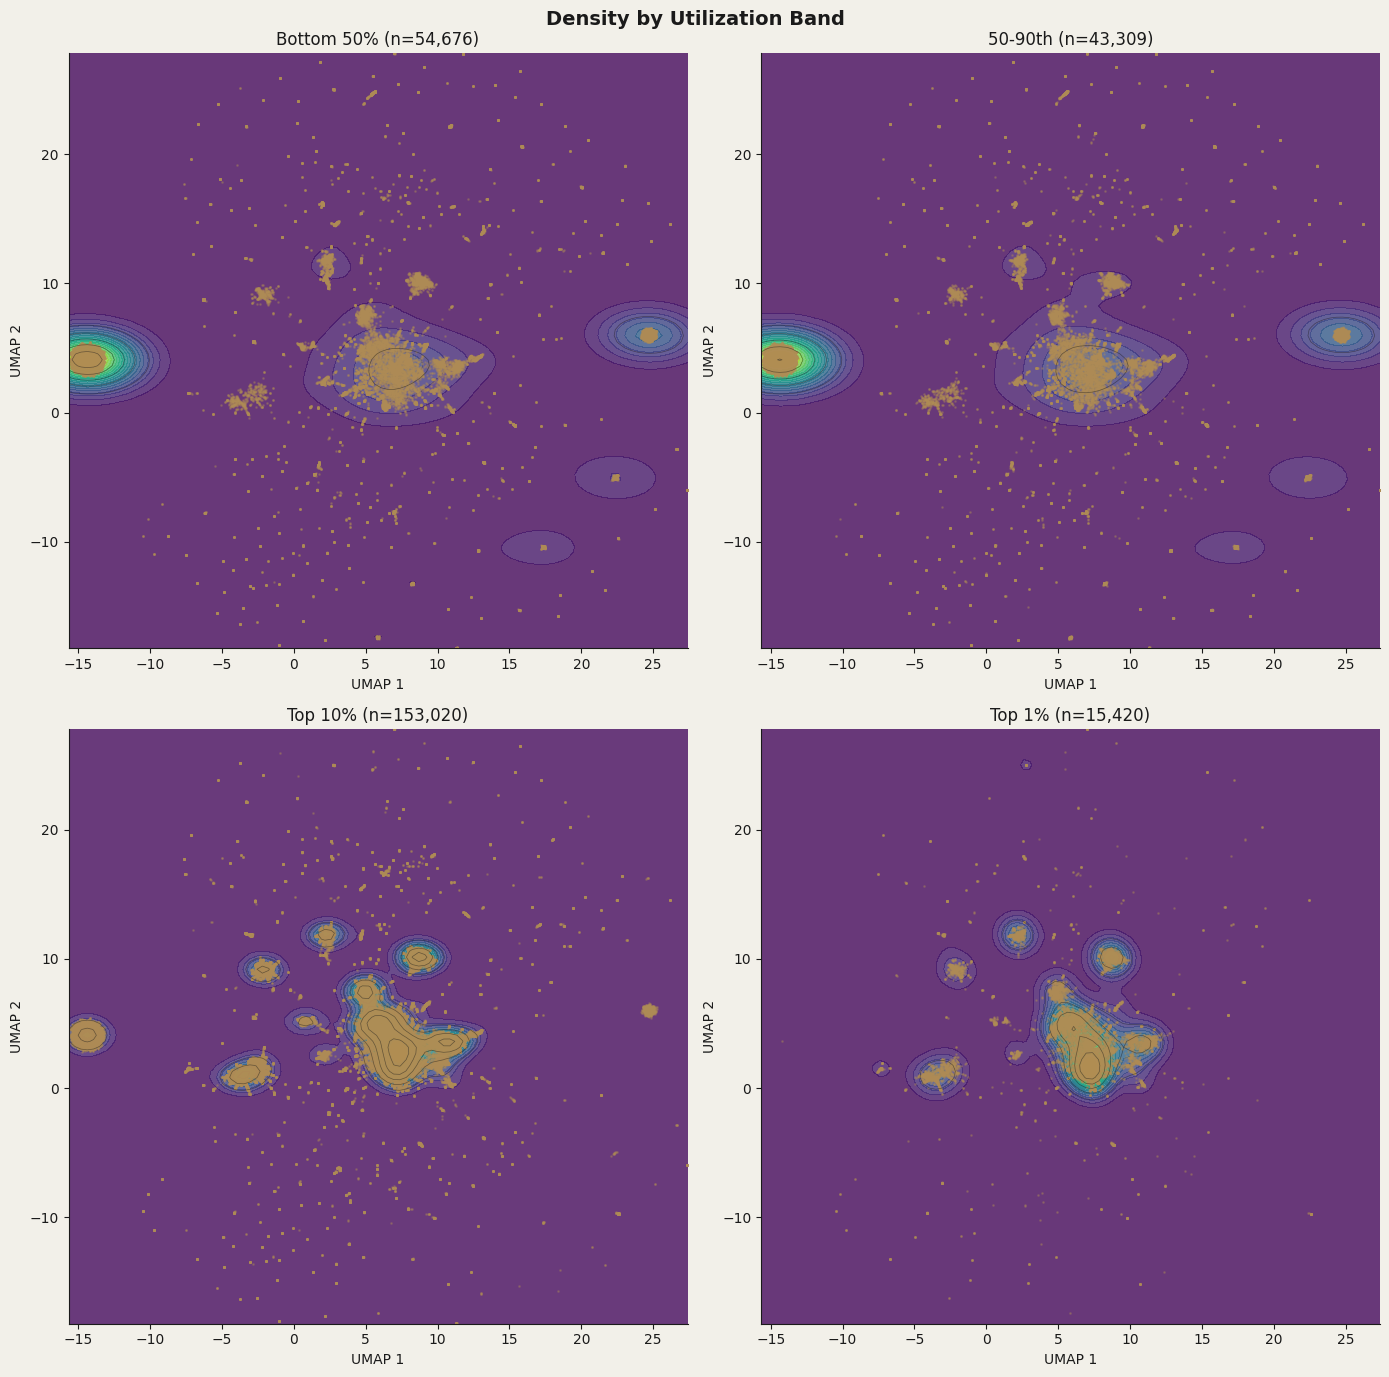

Saved: ../outputs/figures/hexbin_utilization.png


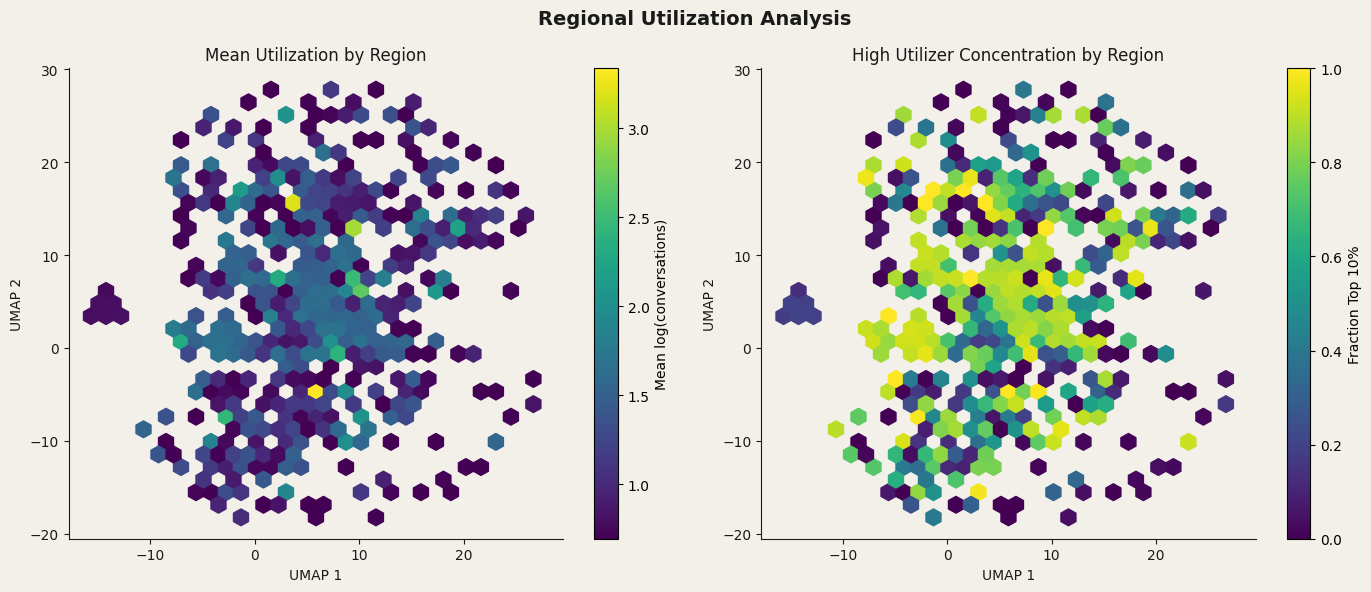

In [43]:
# ============================================================
# Density Analysis: Where Do High Utilizers Concentrate?
# ============================================================

print("="*70)
print("DENSITY ANALYSIS: HIGH VS LOW UTILIZER REGIONS")
print("="*70)

# Define utilization bands
percentiles = sample_df['utilization_percentile'].to_numpy()
bands = [
    ('Bottom 50%', percentiles < 50),
    ('50-90th', (percentiles >= 50) & (percentiles < 90)),
    ('Top 10%', percentiles >= 90),
    ('Top 1%', percentiles >= 99),
]

# Compute KDE for each band
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
fig.patch.set_facecolor(BRAND['paper'])
fig.suptitle('Density by Utilization Band', fontsize=14, fontweight='bold', color=BRAND['ink'])

for ax, (band_name, mask) in zip(axes.flat, bands):
    points = embedding_2d[mask]
    
    if len(points) > 100:
        # Create grid for density estimation
        x_grid = np.linspace(embedding_2d[:, 0].min(), embedding_2d[:, 0].max(), 100)
        y_grid = np.linspace(embedding_2d[:, 1].min(), embedding_2d[:, 1].max(), 100)
        X, Y = np.meshgrid(x_grid, y_grid)
        positions = np.vstack([X.ravel(), Y.ravel()])
        
        # KDE
        kde = gaussian_kde(points.T)
        Z = kde(positions).reshape(X.shape)
        
        # Plot contours
        ax.contourf(X, Y, Z, levels=20, cmap='viridis', alpha=0.8)
        ax.contour(X, Y, Z, levels=5, colors=BRAND['ink'], linewidths=0.5, alpha=0.5)
    
    ax.scatter(points[:, 0], points[:, 1], c=BRAND['gold'], s=1, alpha=0.3)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(f'{band_name} (n={len(points):,})')
    apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'density_by_utilization_band')
plt.show()

# ============================================================
# Hexbin Analysis: Mean Utilization by Region
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BRAND['paper'])
fig.suptitle('Regional Utilization Analysis', fontsize=14, fontweight='bold', color=BRAND['ink'])

# Panel 1: Mean log(conversations) by hexbin
ax = axes[0]
hb = ax.hexbin(
    embedding_2d[:, 0], embedding_2d[:, 1],
    C=sample_df['log_conversations'].to_numpy(),
    reduce_C_function=np.mean,
    gridsize=30, cmap='viridis', mincnt=5
)
plt.colorbar(hb, ax=ax, label='Mean log(conversations)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Mean Utilization by Region')
apply_phronos_style(ax)

# Panel 2: Fraction of high utilizers by hexbin
ax = axes[1]
is_top10 = (sample_df['utilization_percentile'] >= 90).to_numpy().astype(float)
hb = ax.hexbin(
    embedding_2d[:, 0], embedding_2d[:, 1],
    C=is_top10,
    reduce_C_function=np.mean,
    gridsize=30, cmap='viridis', mincnt=5
)
plt.colorbar(hb, ax=ax, label='Fraction Top 10%')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('High Utilizer Concentration by Region')
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'hexbin_utilization')
plt.show()


In [44]:
# ============================================================
# Topic Modeling with BERTopic
# ============================================================

print("="*70)
print("TOPIC MODELING WITH BERTOPIC")
print("="*70)

# Custom vectorizer for interpretable topics
vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=10
)

# Initialize BERTopic with pre-computed embeddings and UMAP
# Use the fitted UMAP reducer for consistency
print("Fitting BERTopic...")
topic_model = BERTopic(
    embedding_model=embed_model,
    umap_model=reducer,
    vectorizer_model=vectorizer,
    nr_topics='auto',
    top_n_words=10,
    verbose=True
)

# Fit on texts using pre-computed embeddings
topics, probs = topic_model.fit_transform(texts, embeddings)

n_topics = len(set(topics)) - 1  # -1 for outlier topic
print(f"Topics discovered: {n_topics}")

# Add topics to sample
sample_df = sample_df.with_columns([
    pl.Series('topic', topics),
    pl.Series('topic_prob', probs.max(axis=1) if len(probs.shape) > 1 else probs)
])


TOPIC MODELING WITH BERTOPIC
Fitting BERTopic...


2026-01-03 11:53:40,163 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Sat Jan  3 11:53:40 2026 Construct fuzzy simplicial set
Sat Jan  3 11:53:40 2026 Finding Nearest Neighbors
Sat Jan  3 11:53:40 2026 Building RP forest with 30 trees
Sat Jan  3 11:53:51 2026 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	 3  /  18
	 4  /  18
	 5  /  18
	Stopping threshold met -- exiting after 5 iterations
Sat Jan  3 11:54:28 2026 Finished Nearest Neighbor Search
Sat Jan  3 11:54:29 2026 Construct embedding


Epochs completed:   1%|            2/200 [00:00]

	completed  0  /  200 epochs


...

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [02:52]


Sat Jan  3 12:05:29 2026 Finished embedding


2026-01-03 12:05:30,274 - BERTopic - Dimensionality - Completed ✓
2026-01-03 12:05:30,278 - BERTopic - Cluster - Start clustering the reduced embeddings
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable 	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to av

Topics discovered: 809


In [ ]:
# ============================================================
# Analyze Utilization by Topic
# ============================================================

print("="*70)
print("UTILIZATION BY TOPIC")
print("="*70)

# Get topic info from BERTopic
topic_info = topic_model.get_topic_info()
print(f"\nTop 20 Topics by Size:")
print(topic_info.head(20))

# Mean utilization by topic
topic_utilization = sample_df.group_by('topic').agg([
    pl.col('log_conversations').mean().alias('mean_log_conv'),
    pl.col('utilization_percentile').mean().alias('mean_percentile'),
    pl.col('n_conversations').median().alias('median_conversations'),
    pl.len().alias('n_users'),
    (pl.col('utilization_percentile') >= 90).sum().alias('n_top10'),
]).filter(pl.col('topic') >= 0)  # Exclude outlier topic -1

# Add topic labels from BERTopic
topic_labels = {row['Topic']: row['Name'] for _, row in topic_info.iterrows()}
topic_utilization = topic_utilization.with_columns([
    pl.col('topic').map_elements(lambda t: topic_labels.get(t, f'Topic {t}'), return_dtype=pl.Utf8).alias('topic_label')
])

# Sort by utilization
topic_utilization = topic_utilization.sort('mean_percentile', descending=True)

print("\n" + "="*70)
print("TOPICS RANKED BY UTILIZATION")
print("="*70)
print(f"{'Topic':<40} {'N Users':>10} {'Mean %ile':>10} {'Median Conv':>12} {'N Top10%':>10}")
print("-"*82)

for row in topic_utilization.head(20).iter_rows(named=True):
    label = row['topic_label'][:40] if row['topic_label'] else f"Topic {row['topic']}"
    print(f"{label:<40} {row['n_users']:>10,} {row['mean_percentile']:>10.1f} "
          f"{row['median_conversations']:>12.0f} {row['n_top10']:>10,}")

# ============================================================
# Visualization: Topic Landscape with Utilization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BRAND['paper'])
fig.suptitle('Topic Landscape and Utilization', fontsize=14, fontweight='bold', color=BRAND['ink'])

# Panel 1: UMAP colored by topic (top 10 topics by utilization)
ax = axes[0]
top_topics = topic_utilization.head(10)['topic'].to_list()
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for i, topic in enumerate(top_topics):
    mask = (sample_df['topic'] == topic).to_numpy()
    ax.scatter(
        embedding_2d[mask, 0], embedding_2d[mask, 1],
        c=[colors[i]], s=5, alpha=0.6,
        label=(topic_labels.get(topic, f'Topic {topic}') or f'Topic {topic}')[:30]
    )

# Plot others in gray
other_mask = ~sample_df['topic'].is_in(top_topics).to_numpy()
ax.scatter(
    embedding_2d[other_mask, 0], embedding_2d[other_mask, 1],
    c='lightgray', s=1, alpha=0.2, label='Other topics'
)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Top 10 Topics by Utilization')
ax.legend(loc='upper left', fontsize=8, markerscale=3, facecolor=BRAND['paper'])
apply_phronos_style(ax)

# Panel 2: Topic utilization bar chart
ax = axes[1]
top_20 = topic_utilization.head(20)
y_pos = np.arange(len(top_20))
ax.barh(y_pos, top_20['mean_percentile'].to_numpy(), color=BRAND['gold'], edgecolor=BRAND['ink'])
ax.set_yticks(y_pos)
labels = [
    (row['topic_label'][:35] if row['topic_label'] else f"Topic {row['topic']}")
    for row in top_20.iter_rows(named=True)
]
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('Mean Utilization Percentile')
ax.set_title('Topics Ranked by Utilization')
ax.axvline(x=50, color=BRAND['ink'], linestyle='--', alpha=0.5, label='Population median')
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'topic_utilization_landscape')
plt.show()


In [45]:
# ============================================================
# Regression: Can Embeddings Predict Utilization?
# ============================================================

print("="*70)
print("REGRESSION: EMBEDDING → UTILIZATION")
print("="*70)

# Target: log(conversations) - continuous utilization
y = sample_df['log_conversations'].to_numpy()

# Features: raw embeddings (384 dim)
X = embeddings

print(f"Features: {X.shape[1]} embedding dimensions")
print(f"Target: log(conversations), range [{y.min():.2f}, {y.max():.2f}]")

# Split for cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Model comparison
models = {
    'Ridge (α=1)': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Ridge (α=10)': Ridge(alpha=10.0, random_state=RANDOM_STATE),
    'Ridge (α=100)': Ridge(alpha=100.0, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, 
                                           random_state=RANDOM_STATE, n_jobs=-1),
}

print("\nCross-validated R² scores:")
print("-"*50)

best_model = None
best_r2 = -np.inf
best_model_name = None

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kfold, scoring='r2')
    mean_r2 = scores.mean()
    std_r2 = scores.std()
    print(f"{name:<20}: R² = {mean_r2:.3f} ± {std_r2:.3f}")
    
    if mean_r2 > best_r2:
        best_r2 = mean_r2
        best_model = model
        best_model_name = name

print(f"\nBest model: {best_model_name} with R² = {best_r2:.3f}")

# Fit best model on all data for later use
final_model = best_model
final_model.fit(X, y)

# Baseline: predict mean (R² = 0 by definition)
print(f"Baseline (predict mean): R² = 0.000")
print(f"Improvement over baseline: +{best_r2:.3f}")


REGRESSION: EMBEDDING → UTILIZATION
Features: 384 embedding dimensions
Target: log(conversations), range [0.69, 10.57]

Cross-validated R² scores:
--------------------------------------------------
Ridge (α=1)         : R² = 0.262 ± 0.003
Ridge (α=10)        : R² = 0.262 ± 0.003
Ridge (α=100)       : R² = 0.256 ± 0.003
Random Forest       : R² = 0.284 ± 0.002

Best model: Random Forest with R² = 0.284
Baseline (predict mean): R² = 0.000
Improvement over baseline: +0.284


Saved: ../outputs/figures/embedding_regression_performance.png


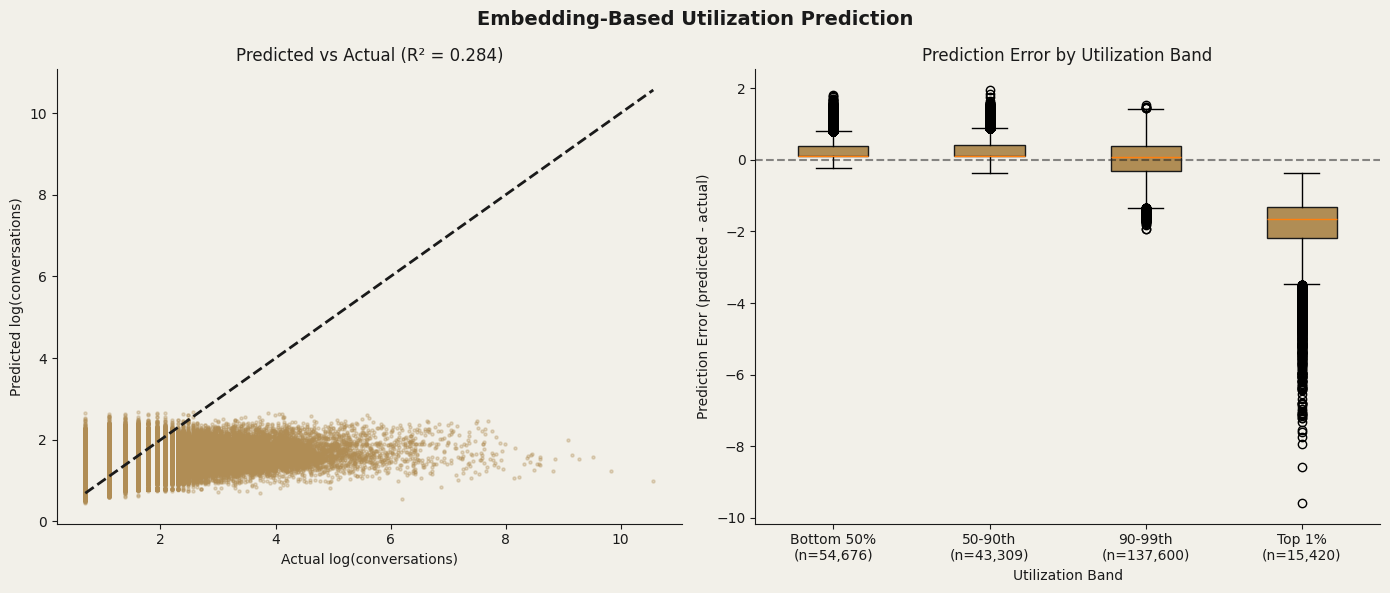

In [46]:
# ============================================================
# Regression Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BRAND['paper'])
fig.suptitle('Embedding-Based Utilization Prediction', fontsize=14, fontweight='bold', color=BRAND['ink'])

# Get cross-validated predictions
y_pred = cross_val_predict(Ridge(alpha=10.0), X, y, cv=kfold)

# Panel 1: Predicted vs actual scatter
ax = axes[0]
ax.scatter(y, y_pred, c=BRAND['gold'], alpha=0.3, s=5, rasterized=True)
ax.plot([y.min(), y.max()], [y.min(), y.max()], color=BRAND['ink'], linestyle='--', linewidth=2)
ax.set_xlabel('Actual log(conversations)')
ax.set_ylabel('Predicted log(conversations)')
ax.set_title(f'Predicted vs Actual (R² = {best_r2:.3f})')
apply_phronos_style(ax)

# Panel 2: Prediction error by utilization band
ax = axes[1]
errors = y_pred - y
percentiles = sample_df['utilization_percentile'].to_numpy()

bands = [(0, 50, 'Bottom 50%'), (50, 90, '50-90th'), (90, 99, '90-99th'), (99, 100, 'Top 1%')]
band_errors = []
band_labels = []

for low, high, label in bands:
    mask = (percentiles >= low) & (percentiles < high)
    if mask.sum() > 0:
        band_errors.append(errors[mask])
        band_labels.append(f'{label}\n(n={mask.sum():,})')

bp = ax.boxplot(band_errors, labels=band_labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor(BRAND['gold'])
    patch.set_edgecolor(BRAND['ink'])
ax.axhline(y=0, color=BRAND['ink'], linestyle='--', alpha=0.5)
ax.set_xlabel('Utilization Band')
ax.set_ylabel('Prediction Error (predicted - actual)')
ax.set_title('Prediction Error by Utilization Band')
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'embedding_regression_performance')
plt.show()


In [50]:
# ============================================================
# Nearest Neighbor Personal Inference Prototype
# ============================================================

import scipy.stats  # Explicit import to avoid shadowing by loop variable 'stats'

print("="*70)
print("NEAREST NEIGHBOR PERSONAL INFERENCE")
print("="*70)

# Fit nearest neighbors model
N_NEIGHBORS = 50  # Find 50 most similar users

nn_model = NearestNeighbors(
    n_neighbors=N_NEIGHBORS,
    metric='cosine',
    algorithm='brute'  # Exact for cosine
)
nn_model.fit(embeddings)
print(f"Nearest neighbors model fitted with {N_NEIGHBORS} neighbors")

def personal_inference(prompt_text, sample_df, embeddings, nn_model, embed_model, 
                       n_neighbors=50, show_examples=5):
    """
    Given a new prompt, provide personal inference about likely utilization pattern.
    
    Returns dict with:
    - embedding location
    - similar user statistics
    - example prompts from similar users
    - predicted utilization
    """
    # Embed the new prompt
    new_embedding = embed_model.encode([prompt_text], normalize_embeddings=True)
    
    # Find nearest neighbors
    distances, indices = nn_model.kneighbors(new_embedding, n_neighbors=n_neighbors)
    distances = distances[0]
    indices = indices[0]
    
    # Get neighbor data as numpy for indexing
    neighbor_percentiles = sample_df['utilization_percentile'].to_numpy()[indices]
    neighbor_n_conv = sample_df['n_conversations'].to_numpy()[indices]
    neighbor_topics = sample_df['topic'].to_numpy()[indices]
    neighbor_texts = [sample_df['first_turn'].to_list()[i] for i in indices[:show_examples]]
    
    results = {
        'query_prompt': prompt_text[:200] + '...' if len(prompt_text) > 200 else prompt_text,
        'n_neighbors': n_neighbors,
        'mean_similarity': 1 - distances.mean(),  # Convert distance to similarity
        
        # Utilization statistics of similar users
        'neighbor_stats': {
            'median_conversations': np.median(neighbor_n_conv),
            'mean_conversations': np.mean(neighbor_n_conv),
            'p10_conversations': np.percentile(neighbor_n_conv, 10),
            'p90_conversations': np.percentile(neighbor_n_conv, 90),
            'mean_percentile': np.mean(neighbor_percentiles),
            'pct_top10': (neighbor_percentiles >= 90).mean() * 100,
            'pct_top1': (neighbor_percentiles >= 99).mean() * 100,
        },
        
        # Topic distribution of neighbors (use scipy.stats to avoid shadowing)
        'top_topic': int(scipy.stats.mode(neighbor_topics, keepdims=False).mode) if len(neighbor_topics) > 0 else -1,
        
        # Example prompts from similar users
        'example_prompts': neighbor_texts,
    }
    
    return results

# Demo with example prompts
demo_prompts = [
    "Help me debug this Python function that's throwing an IndexError",
    "I'm feeling lonely tonight, can we just chat?",
    "You are a medieval knight named Sir Aldric. You've just arrived at the castle...",
    "What's the capital of France?",
    "Write a poem about the ocean at sunset",
]

print("\nPERSONAL INFERENCE DEMO")
print("="*70)

for prompt in demo_prompts:
    results = personal_inference(prompt, sample_df, embeddings, nn_model, embed_model)
    
    print(f"\n{'─'*70}")
    print(f"QUERY: {results['query_prompt']}")
    print(f"{'─'*70}")
    print(f"Neighbors found: {results['n_neighbors']} (mean similarity: {results['mean_similarity']:.3f})")
    print(f"\nSIMILAR USER STATISTICS:")
    stats_dict = results['neighbor_stats']
    print(f"  Median conversations: {stats_dict['median_conversations']:.0f}")
    print(f"  Range (10th-90th): {stats_dict['p10_conversations']:.0f} - {stats_dict['p90_conversations']:.0f}")
    print(f"  Mean utilization percentile: {stats_dict['mean_percentile']:.1f}")
    print(f"  % in top 10%: {stats_dict['pct_top10']:.1f}%")
    print(f"  % in top 1%: {stats_dict['pct_top1']:.1f}%")


NEAREST NEIGHBOR PERSONAL INFERENCE
Nearest neighbors model fitted with 50 neighbors

PERSONAL INFERENCE DEMO

──────────────────────────────────────────────────────────────────────
QUERY: Help me debug this Python function that's throwing an IndexError
──────────────────────────────────────────────────────────────────────
Neighbors found: 50 (mean similarity: 0.504)

SIMILAR USER STATISTICS:
  Median conversations: 3
  Range (10th-90th): 2 - 9
  Mean utilization percentile: 90.3
  % in top 10%: 90.0%
  % in top 1%: 4.0%

──────────────────────────────────────────────────────────────────────
QUERY: I'm feeling lonely tonight, can we just chat?
──────────────────────────────────────────────────────────────────────
Neighbors found: 50 (mean similarity: 0.482)

SIMILAR USER STATISTICS:
  Median conversations: 2
  Range (10th-90th): 1 - 5
  Mean utilization percentile: 84.6
  % in top 10%: 84.0%
  % in top 1%: 4.0%

──────────────────────────────────────────────────────────────────────
QUE

In [49]:
# ============================================================
# Holdout Validation: 2025 New Users
# ============================================================

print("="*70)
print("HOLDOUT VALIDATION: 2025 NEW USERS")
print("="*70)

# Define cutoff
TRAIN_TEST_CUTOFF = pl.datetime(2025, 1, 1)

# Identify new users in 2025 (not in our training sample)
user_first_dates = df.group_by('user_id').agg(
    pl.col('timestamp').min().alias('first_conv_date')
)

test_user_ids = set(
    user_first_dates.filter(pl.col('first_conv_date') >= TRAIN_TEST_CUTOFF)['user_id'].to_list()
)

# Exclude users already in sample
test_user_ids = test_user_ids - sample_user_ids

print(f"2025 new users (not in sample): {len(test_user_ids):,}")

if len(test_user_ids) < 1000:
    print("\nNot enough 2025 users for holdout validation.")
    print("This may happen if the dataset doesn't include recent data.")
else:
    # Sample test users
    TEST_SAMPLE_SIZE = min(10000, len(test_user_ids))
    test_sample_ids = set(np.random.choice(list(test_user_ids), size=TEST_SAMPLE_SIZE, replace=False))
    
    # Get first conversation hashes for test users
    test_first_conv = df.filter(
        pl.col('user_id').is_in(test_sample_ids)
    ).sort(['user_id', 'timestamp']).group_by('user_id').first()
    
    test_conv_hashes = set(test_first_conv['conversation_hash'].to_list())
    print(f"Test sample: {len(test_sample_ids):,} users")
    
    # Extract first turns for test users (file-by-file)
    test_first_turns = {}
    print("Extracting test user first turns...")
    
    for file_idx, parquet_file in enumerate(parquet_files):
        file_data = pl.read_parquet(parquet_file, columns=['conversation_hash', 'conversation'])
        file_filtered = file_data.filter(pl.col('conversation_hash').is_in(list(test_conv_hashes)))
        
        for row in file_filtered.iter_rows(named=True):
            conv_hash = row['conversation_hash']
            if conv_hash not in test_first_turns:
                first_turn = extract_first_user_turn(row['conversation'])
                if first_turn:
                    test_first_turns[conv_hash] = first_turn
        
        del file_data, file_filtered
        gc.collect()
    
    print(f"  Extracted {len(test_first_turns):,} first turns")
    
    # Build test sample with utilization metrics
    test_user_stats = user_stats.filter(pl.col('user_id').is_in(test_sample_ids))
    
    test_records = []
    for row in test_first_conv.iter_rows(named=True):
        user_id = row['user_id']
        conv_hash = row['conversation_hash']
        
        user_stat = test_user_stats.filter(pl.col('user_id') == user_id)
        if len(user_stat) == 0:
            continue
        user_stat = user_stat.row(0, named=True)
        
        first_turn = test_first_turns.get(conv_hash)
        if first_turn is None or len(first_turn.strip()) <= 10:
            continue
        
        test_records.append({
            'user_id': user_id,
            'first_turn': first_turn,
            'log_conversations': user_stat['log_conversations'],
        })
    
    if len(test_records) > 100:
        test_df = pl.DataFrame(test_records)
        print(f"Test dataframe: {len(test_df):,} users")
        
        # Generate embeddings for test users
        test_texts = test_df['first_turn'].to_list()
        test_embeddings = embed_model.encode(
            test_texts,
            show_progress_bar=True,
            batch_size=256,
            normalize_embeddings=True
        )
        
        # Predict using trained model
        test_y = test_df['log_conversations'].to_numpy()
        test_y_pred = final_model.predict(test_embeddings)
        
        # Evaluate
        test_r2 = r2_score(test_y, test_y_pred)
        test_mae = mean_absolute_error(test_y, test_y_pred)
        
        print(f"\nTEST SET RESULTS:")
        print(f"  R²: {test_r2:.3f}")
        print(f"  MAE: {test_mae:.3f}")
        print(f"\nTraining R² (CV): {best_r2:.3f}")
        print(f"Generalization gap: {best_r2 - test_r2:.3f}")
    else:
        print("Not enough valid test users after extraction.")


HOLDOUT VALIDATION: 2025 NEW USERS
2025 new users (not in sample): 0

Not enough 2025 users for holdout validation.
This may happen if the dataset doesn't include recent data.


In [ ]:
# ============================================================
# Output Summary
# ============================================================

print("="*70)
print("OUTPUT SUMMARY")
print("="*70)

outputs = {
    'Data files': [
        '../outputs/data/first_turn_embeddings.npy',
        '../outputs/data/embedding_sample.parquet',
    ],
    'Figures': [
        'utilization_distribution.png',
        'umap_utilization_overview.png',
        'density_by_utilization_band.png',
        'hexbin_utilization.png',
        'topic_utilization_landscape.png',
        'embedding_regression_performance.png',
    ],
    'Models': [
        f'UMAP reducer (fitted, n_neighbors={reducer.n_neighbors})',
        f'BERTopic model (fitted, {n_topics} topics discovered)',
        f'Ridge regression (fitted, α=10, R²={best_r2:.3f})',
        f'Nearest neighbors index (fitted, k={N_NEIGHBORS})',
    ],
    'Key findings': [
        f'Topics discovered: {n_topics}',
        f'Embedding → utilization R²: {best_r2:.3f}',
        f'Sample size: {len(sample_df):,} users',
        f'Top 10% users in sample: {(sample_df["utilization_percentile"] >= 90).sum():,}',
    ]
}

for category, items in outputs.items():
    print(f"\n{category}:")
    for item in items:
        print(f"  - {item}")

# Verify generated figures exist
import os
figures_dir = '../outputs/figures'
print(f"\n{'─'*70}")
print("GENERATED FIGURES:")
for fig_name in outputs['Figures']:
    path = f'{figures_dir}/{fig_name}'
    exists = os.path.exists(path)
    status = "✓" if exists else "✗"
    print(f"  {status} {fig_name}")

print("\n" + "="*70)
print("Semantic Exploration Complete.")
print("="*70)
